# 03 - BV vs THINGS RDM Comparison (Included Categories)

This notebook compares representational dissimilarity matrices (RDMs) between BabyView (BV) and THINGS category embeddings.

It:
- Intersects an include list with categories present in all four embedding tables (BV/THINGS × CLIP/DINOv3). **BV** and **THINGS** both use `exemplar_set_embeddings/{valid85|valid129}/{bv|things}_{clip|dinov3}_exemplar_avg_zscore_within_{...}.csv` from notebooks **06** (BV) and **07** (THINGS).
- Uses the same category sets as `01_long_tailed_distribution.ipynb` and `02_category-wise_cosine_sim.ipynb`: set **`CATEGORY_SET`** in setup (`valid85` or `valid129`, default **`valid129`**). Lists are `data/included_categories_valid85.txt` and `data/included_categories_valid129.txt`.
- Computes category-level cosine-distance RDMs for BV and THINGS
- Runs the comparison for both CLIP and DINOv3 embeddings
- Writes results and figures under **`supplemental_results_valid85cats_04202026/`** or **`main_results_valid129s_04202026/`** (same layout as notebooks 01–02). Output filenames use the suffix `filtered-{threshold}_{CATEGORY_SET}` (e.g. `..._valid129.csv`).

**Dual run (both category sets):** from repo root, `python analysis/preprint-2026/run_03_rdm_dual.py` (requires `jupyter nbconvert`), or run all cells twice while changing `CATEGORY_SET` in setup (`valid85`, then `valid129`).

CDI semantic ordering uses `data/long_tailed_dist_prop_included_categories_{valid85|valid129}.csv` from notebook 01 for the same `CATEGORY_SET`.

Run from `analysis/preprint-2026/` so paths resolve.

In [16]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau

In [17]:
# Paths and run configuration
ROOT = Path.cwd().resolve().parent.parent
DATA_DIR = ROOT / "data"
ANALYSIS_DIR = ROOT / "analysis"
PREPRINT_DIR = ANALYSIS_DIR / "preprint-2026"

# Select category set here once per run: "valid129" (default) or "valid85".
CATEGORY_SET = "valid85"
CATEGORY_FILES = {
    "valid85": DATA_DIR / "included_categories_valid85.txt",
    "valid129": DATA_DIR / "included_categories_valid129.txt",
}
if CATEGORY_SET not in CATEGORY_FILES:
    raise ValueError(
        f"Unsupported CATEGORY_SET: {CATEGORY_SET!r} (expected one of {sorted(CATEGORY_FILES)})"
    )
INCLUDED_CATEGORIES_TXT = CATEGORY_FILES[CATEGORY_SET]

# Same output roots as 01_long_tailed_distribution.ipynb / 02_category-wise_cosine_sim.ipynb
if CATEGORY_SET == "valid85":
    OUTPUT_RUN_ROOT = PREPRINT_DIR / "supplemental_results_valid85cats_04302026"
else:
    OUTPUT_RUN_ROOT = PREPRINT_DIR / "main_results_valid129s_04302026"

RESULTS_DIR = OUTPUT_RUN_ROOT / "results"
FIGURES_DIR = OUTPUT_RUN_ROOT / "figures"

# Filename suffix for this run (aligned with 02: e.g. *_filtered-0.27_valid129.csv)
OUTPUT_RUN_TAG = CATEGORY_SET

THRESHOLD = "0.27"
# Canonical token used in output filenames to avoid accidental "filtered-0" names.
THRESHOLD_TOKEN = f"{float(THRESHOLD):.2f}"
if THRESHOLD_TOKEN in {"0", "0.0", "0.00"}:
    raise ValueError(f"Suspicious THRESHOLD for filenames: {THRESHOLD}")

EXEMPLAR_EMBED_DIR = PREPRINT_DIR / "exemplar_set_embeddings" / CATEGORY_SET
PER_CLASS_PRECISION_CSV = ROOT / "annotation" / "per_class_validation_data.csv"
PER_FILE_PRECISION_CSV = ROOT / "annotation" / "per_file_precision_data.csv"
SAMPLED_EXEMPLAR_CSV = ROOT / "annotation" / "sampled_object_crops_100_bucket_assignments_100ex_8subj_per_video_cap_babyview_only.csv"
PRECISION_THRESHOLD = 0.6  # same as notebooks 01/02 (per-class / per-file / sampled exemplar gates)
# CDI column aligns with cdi_words.csv (rebuild intermediate: analysis/preprint-2026/01_long_tailed_distribution.ipynb; optional: build_long_tailed_included_categories.py)
CDI_SEMANTIC_CSV = DATA_DIR / f"long_tailed_dist_prop_included_categories_{CATEGORY_SET}.csv"

CDI_SEMANTIC_ORDER = [
    "animals",
    "body_parts",
    "clothing",
    "food_drink",
    "furniture_rooms",
    "household",
    "outside",
    "toys",
    "vehicles",
    "other",
]
CDI_SEMANTIC_COLORS = {
    "animals": "#4DB8A8",
    "body_parts": "#E87A5F",
    "clothing": "#9B7EC8",
    "food_drink": "#E8A54C",
    "furniture_rooms": "#6BAB7A",
    "household": "#D97B9E",
    "outside": "#5B9BD5",
    "people": "#E8C44C",
    "toys": "#B07CC8",
    "vehicles": "#6BA3D5",
    "other": "#8B9A9E",
}

EMBEDDING_PAIRS = {
    "clip": {
        "bv": EXEMPLAR_EMBED_DIR / f"bv_clip_exemplar_avg_zscore_within_{CATEGORY_SET}.csv",
        "things": EXEMPLAR_EMBED_DIR / f"things_clip_exemplar_avg_zscore_within_{CATEGORY_SET}.csv",
    },
    "dinov3": {
        "bv": EXEMPLAR_EMBED_DIR / f"bv_dinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv",
        "things": EXEMPLAR_EMBED_DIR / f"things_dinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv",
    },
}

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"[03_rdm_comparison] CATEGORY_SET={CATEGORY_SET!r}")
print(f"Root: {ROOT}")
print(f"Run output root: {OUTPUT_RUN_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")
print(f"Filename suffix (OUTPUT_RUN_TAG): {OUTPUT_RUN_TAG}")
print(f"Included categories: {INCLUDED_CATEGORIES_TXT}")
print(f"CDI semantic mapping: {CDI_SEMANTIC_CSV}")
for model_name, files in EMBEDDING_PAIRS.items():
    print(f"[{model_name}] BV: {files['bv']}")
    print(f"[{model_name}] THINGS: {files['things']}")

[03_rdm_comparison] CATEGORY_SET='valid85'
Root: /home/j7yang/babyview-projects/vss2026/object-detection
Run output root: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026
Results dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results
Figures dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures
Filename suffix (OUTPUT_RUN_TAG): valid85
Included categories: /home/j7yang/babyview-projects/vss2026/object-detection/data/included_categories_valid85.txt
CDI semantic mapping: /home/j7yang/babyview-projects/vss2026/object-detection/data/long_tailed_dist_prop_included_categories_valid85.csv
[clip] BV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/exemplar_set_embeddings/valid85/bv_clip_exemplar_avg_zscore_within_valid85.csv
[clip] THIN

In [18]:
def load_embedding_csv(csv_path: Path):
    df = pd.read_csv(csv_path)

    # Handle common category-label column patterns.
    if "category" in df.columns:
        categories = df["category"].astype(str).str.strip().str.lower().tolist()
        embedding_df = df.drop(columns=["category"])
    elif "Unnamed: 0" in df.columns:
        categories = df["Unnamed: 0"].astype(str).str.strip().str.lower().tolist()
        embedding_df = df.drop(columns=["Unnamed: 0"])
    else:
        first_col = df.columns[0]
        first_is_text = pd.api.types.is_object_dtype(df[first_col])
        if first_is_text:
            categories = df[first_col].astype(str).str.strip().str.lower().tolist()
            embedding_df = df.drop(columns=[first_col])
        else:
            categories = [str(c).strip().lower() for c in df.index]
            embedding_df = df.copy()

    # Keep only numeric embedding dimensions.
    embedding_df = embedding_df.select_dtypes(include=[np.number])
    embeddings = embedding_df.to_numpy(dtype=np.float64)

    if len(categories) != embeddings.shape[0]:
        raise ValueError(
            f"Category/embedding row mismatch in {csv_path}: "
            f"{len(categories)} categories vs {embeddings.shape[0]} rows"
        )

    return categories, embeddings


def load_included_categories(txt_path: Path):
    with txt_path.open("r") as f:
        return [line.strip().lower() for line in f if line.strip()]


def load_valid_categories(include_txt: Path, per_class_precision_csv: Path, threshold: float):
    included = load_included_categories(include_txt)

    df_class = pd.read_csv(per_class_precision_csv, usecols=["class", "precision"])
    df_class["class"] = df_class["class"].astype(str).str.strip().str.lower()
    valid_class_set = set(df_class.loc[df_class["precision"] > threshold, "class"])

    return sorted([c for c in included if c in valid_class_set])


def load_valid_sampled_exemplars_by_category(
    per_file_precision_csv: Path,
    sampled_exemplar_csv: Path,
    threshold: float,
):
    df_file = pd.read_csv(per_file_precision_csv, usecols=["filename", "class", "precision"])
    df_file = df_file[df_file["precision"] > threshold].copy()
    df_file["class_norm"] = df_file["class"].astype(str).str.strip().str.lower()
    df_file["stem"] = (
        df_file["filename"]
        .astype(str)
        .str.strip()
        .str.rsplit("/", n=1)
        .str[-1]
        .str.rsplit(".", n=1)
        .str[0]
        .str.lower()
    )

    sampled = pd.read_csv(sampled_exemplar_csv)
    sampled = sampled[sampled["trial_type"] == "regular"].copy()
    sampled["category"] = sampled["category"].astype(str).str.strip().str.lower()
    sampled["stem"] = sampled["stem"].astype(str).str.strip().str.lower()

    valid_pairs = set(zip(df_file["class_norm"], df_file["stem"]))

    by_cat = defaultdict(set)
    for _, row in sampled.iterrows():
        key = (row["category"], row["stem"])
        if key in valid_pairs:
            by_cat[row["category"]].add(row["stem"])

    return {k: set(v) for k, v in by_cat.items()}


def load_cdi_semantic_map(csv_path: Path):
    df = pd.read_csv(csv_path)
    required = {"category", "cdi_semantic"}
    if not required.issubset(df.columns):
        raise ValueError(f"Expected columns {required} in {csv_path}")

    mapping = {}
    for _, row in df[["category", "cdi_semantic"]].dropna().iterrows():
        cat = str(row["category"]).strip().lower()
        sem = str(row["cdi_semantic"]).strip().lower()
        mapping[cat] = sem
    return mapping


def align_embeddings_for_included_categories(
    bv_csv: Path,
    things_csv: Path,
    valid_categories,
    valid_sampled_stems_by_category,
    require_sampled_stems: bool = True,
):
    bv_categories, bv_embeddings = load_embedding_csv(bv_csv)
    th_categories, th_embeddings = load_embedding_csv(things_csv)

    included_set = set([str(c).strip().lower() for c in valid_categories])
    if require_sampled_stems:
        # valid85: match notebooks 01/02 — category must have >=1 validated sampled exemplar stem.
        sampled_set = set(valid_sampled_stems_by_category.keys())
        eligible_set = included_set & sampled_set
    else:
        # valid129: inclusion list ∩ embeddings only (same spirit as notebook 02 cosine tables).
        eligible_set = included_set

    shared_categories = sorted(set(bv_categories) & set(th_categories) & eligible_set)

    bv_idx = {c: i for i, c in enumerate(bv_categories)}
    th_idx = {c: i for i, c in enumerate(th_categories)}

    bv_aligned = np.stack([bv_embeddings[bv_idx[c]] for c in shared_categories], axis=0)
    th_aligned = np.stack([th_embeddings[th_idx[c]] for c in shared_categories], axis=0)

    return shared_categories, bv_aligned, th_aligned


def build_semantic_cluster_order(categories: list[str], cdi_semantic_map: dict):
    sem_rank = {s: i for i, s in enumerate(CDI_SEMANTIC_ORDER)}

    annotated = []
    for i, cat in enumerate(categories):
        sem = cdi_semantic_map.get(cat, "other")
        rank = sem_rank.get(sem, sem_rank["other"])
        annotated.append((i, cat, sem, rank))

    # Preserve BV order within each semantic cluster.
    annotated_sorted = sorted(annotated, key=lambda x: (x[3], x[0]))

    reordered_idx = [x[0] for x in annotated_sorted]
    reordered_categories = [x[1] for x in annotated_sorted]
    reordered_semantics = [x[2] for x in annotated_sorted]

    boundaries = []
    prev = None
    for i, sem in enumerate(reordered_semantics):
        if i > 0 and sem != prev:
            boundaries.append(i)
        prev = sem

    return reordered_idx, reordered_categories, reordered_semantics, boundaries


def reorder_rdm(rdm: np.ndarray, reordered_idx: list[int]):
    idx = np.array(reordered_idx, dtype=int)
    return rdm[np.ix_(idx, idx)]


def compute_rdm(embeddings: np.ndarray):
    # Cosine-distance RDM (1 - cosine similarity)
    return squareform(pdist(embeddings, metric="cosine"))


def vectorize_upper_triangle(rdm: np.ndarray):
    iu = np.triu_indices_from(rdm, k=1)
    return rdm[iu]


def compare_rdm_vectors(vec_a: np.ndarray, vec_b: np.ndarray):
    vec_a = np.asarray(vec_a)
    vec_b = np.asarray(vec_b)
    if vec_a.shape != vec_b.shape:
        raise ValueError(f"RDM vector shape mismatch: {vec_a.shape} vs {vec_b.shape}")

    pr, pp = pearsonr(vec_a, vec_b)
    sr, sp = spearmanr(vec_a, vec_b)
    kr, kp = kendalltau(vec_a, vec_b)
    return {
        "pearson_r": float(pr),
        "pearson_p": float(pp),
        "spearman_r": float(sr),
        "spearman_p": float(sp),
        "kendall_r": float(kr),
        "kendall_p": float(kp),
        "mae": float(np.mean(np.abs(vec_a - vec_b))),
        "rmse": float(np.sqrt(np.mean((vec_a - vec_b) ** 2))),
    }

In [19]:
def _draw_semantic_boundaries(ax, boundaries: list[int]):
    for b in boundaries:
        ax.axhline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)
        ax.axvline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)


def plot_rdm_comparison(
    model_name: str,
    categories: list[str],
    semantics: list[str],
    boundaries: list[int],
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    bv_vec: np.ndarray,
    th_vec: np.ndarray,
    metrics: dict,
    out_prefix: Path,
):
    fig = plt.figure(figsize=(18, 6))

    ax1 = fig.add_subplot(1, 3, 1)
    im1 = ax1.imshow(bv_rdm, cmap="viridis", aspect="equal", vmin=0, vmax=2)
    _draw_semantic_boundaries(ax1, boundaries)
    ax1.set_box_aspect(1)
    ax1.set_title(f"BV RDM ({model_name.upper()}, CDI-clustered)")
    ax1.set_xticks([])
    ax1.set_yticks([])
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(th_rdm, cmap="viridis", aspect="equal", vmin=0, vmax=2)
    _draw_semantic_boundaries(ax2, boundaries)
    ax2.set_box_aspect(1)
    ax2.set_title(f"THINGS RDM ({model_name.upper()}, BV order)")
    ax2.set_xticks([])
    ax2.set_yticks([])
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.scatter(bv_vec, th_vec, s=14, alpha=0.35)
    lo = min(bv_vec.min(), th_vec.min())
    hi = max(bv_vec.max(), th_vec.max())
    ax3.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax3.set_xlabel("BV pairwise dissimilarity")
    ax3.set_ylabel("THINGS pairwise dissimilarity")
    ax3.set_title(
        f"Upper-triangle comparison\n"
        f"Pearson={metrics['pearson_r']:.3f}, Spearman={metrics['spearman_r']:.3f}"
    )

    fig.suptitle(
        f"BV vs THINGS RDM comparison ({model_name.upper()}, n_categories={len(categories)}, run={OUTPUT_RUN_TAG})",
        y=1.02,
    )
    fig.tight_layout()

    png_path = out_prefix.with_suffix(".png")
    pdf_path = out_prefix.with_suffix(".pdf")
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return png_path, pdf_path

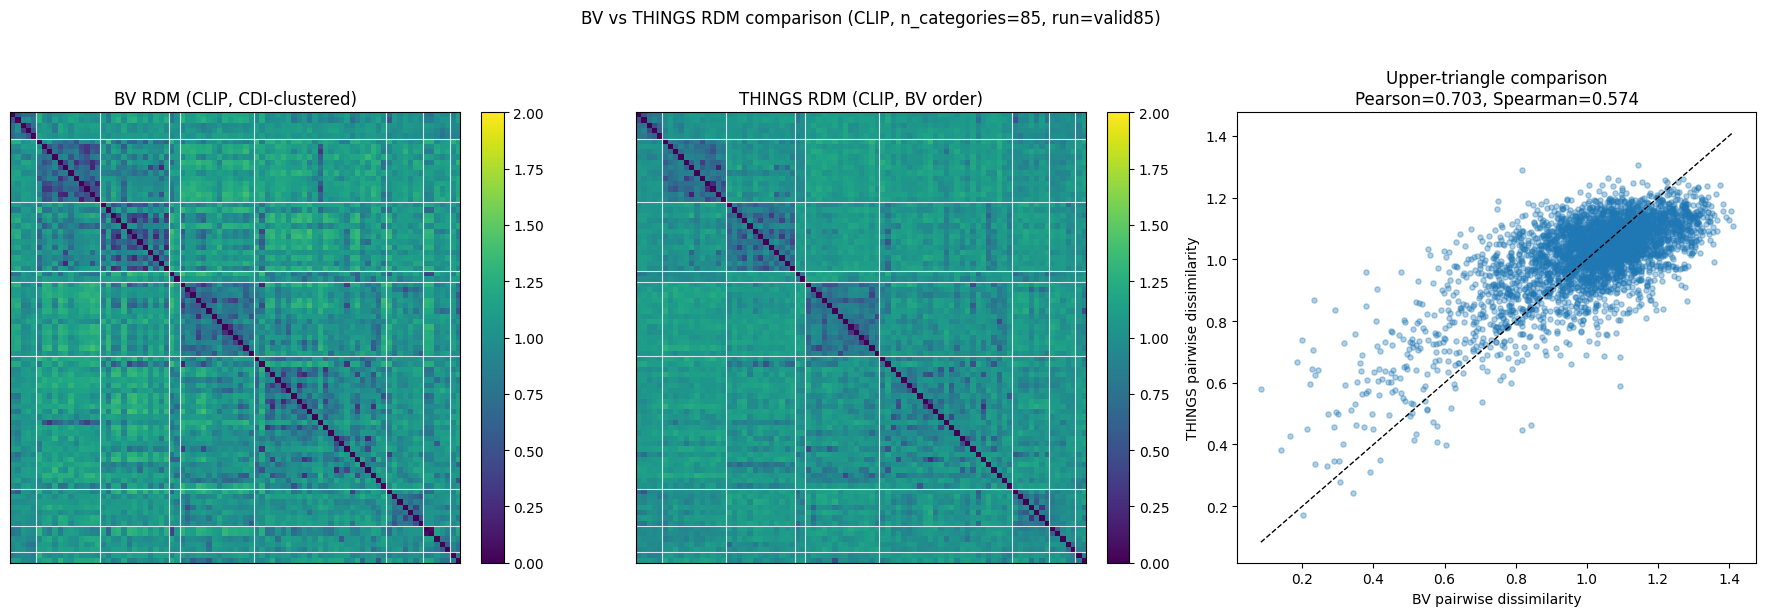

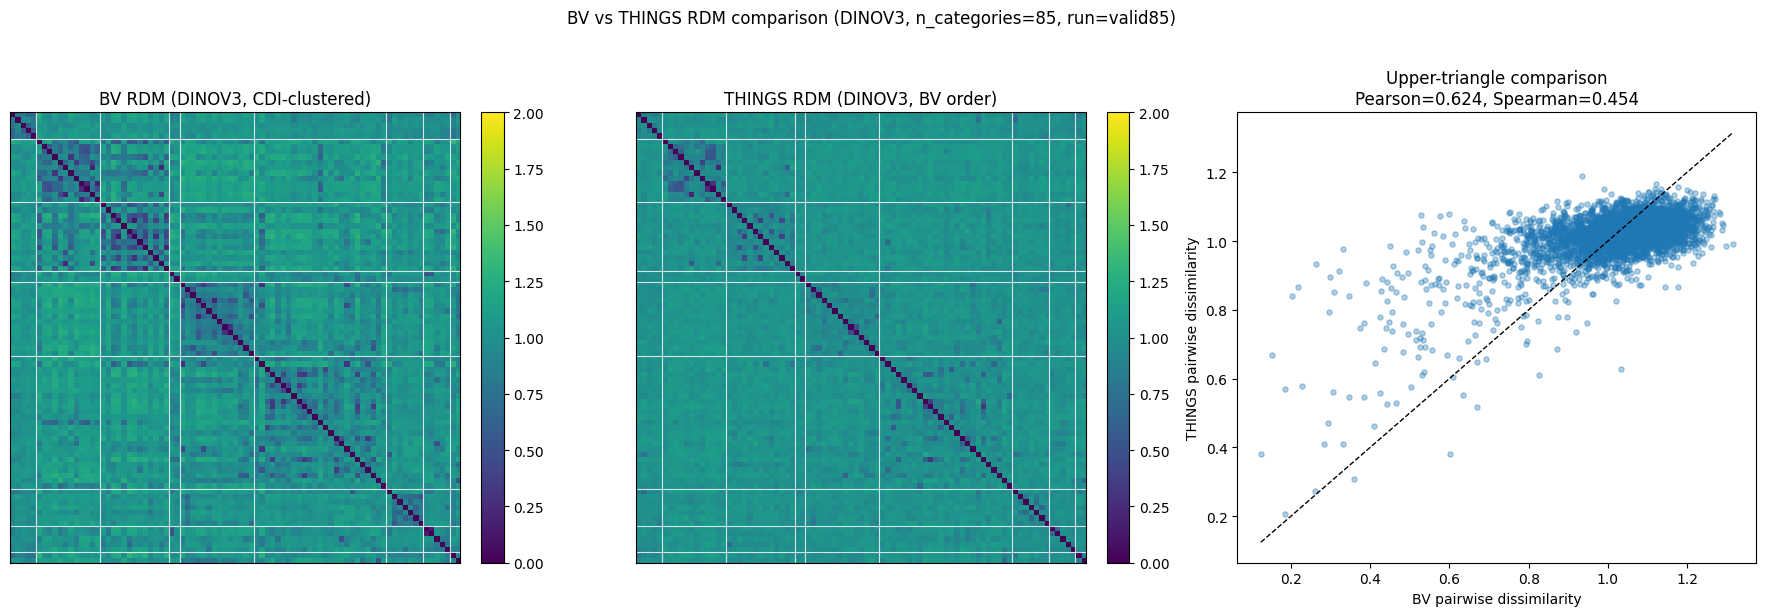

,model,n_categories,n_pairs,n_semantic_clusters,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p,mae,rmse,figure_png,figure_pdf,semantic_counts
0,clip,85,3570,9,0.702888,0.0,0.574390,1.483453e-312,0.410494,5.138657e-296,0.105944,0.134988,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,"{'household': 25, 'furniture_rooms': 14, 'clot..."
1,dinov3,85,3570,9,0.624011,0.0,0.454278,2.443318e-181,0.316904,2.818099e-177,0.088970,0.119250,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,"{'household': 25, 'furniture_rooms': 14, 'clot..."


In [20]:
summary_rows = []

if not CDI_SEMANTIC_CSV.exists():
    raise FileNotFoundError(f"Missing CDI semantic mapping CSV: {CDI_SEMANTIC_CSV}")
cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)

if CATEGORY_SET == "valid129":
    VALID_CATEGORIES = sorted(load_included_categories(INCLUDED_CATEGORIES_TXT))
else:
    VALID_CATEGORIES = load_valid_categories(
        INCLUDED_CATEGORIES_TXT,
        PER_CLASS_PRECISION_CSV,
        PRECISION_THRESHOLD,
    )
VALID_SAMPLED_STEMS_BY_CATEGORY = load_valid_sampled_exemplars_by_category(
    PER_FILE_PRECISION_CSV,
    SAMPLED_EXEMPLAR_CSV,
    PRECISION_THRESHOLD,
)

for model_name, paths in EMBEDDING_PAIRS.items():
    bv_csv = paths["bv"]
    th_csv = paths["things"]

    if not INCLUDED_CATEGORIES_TXT.exists():
        raise FileNotFoundError(f"Missing included categories file: {INCLUDED_CATEGORIES_TXT}")
    if not bv_csv.exists():
        raise FileNotFoundError(f"Missing BV embeddings CSV ({model_name}): {bv_csv}")
    if not th_csv.exists():
        raise FileNotFoundError(f"Missing THINGS embeddings CSV ({model_name}): {th_csv}")

    categories, bv_aligned, th_aligned = align_embeddings_for_included_categories(
        bv_csv,
        th_csv,
        VALID_CATEGORIES,
        VALID_SAMPLED_STEMS_BY_CATEGORY,
        require_sampled_stems=(CATEGORY_SET == "valid85"),
    )

    bv_rdm = compute_rdm(bv_aligned)
    th_rdm = compute_rdm(th_aligned)

    # Organize by CDI semantic clusters using BV order, then apply same order to THINGS.
    reordered_idx, ordered_categories, ordered_semantics, boundaries = build_semantic_cluster_order(
        categories,
        cdi_semantic_map,
    )
    bv_rdm_ord = reorder_rdm(bv_rdm, reordered_idx)
    th_rdm_ord = reorder_rdm(th_rdm, reordered_idx)

    bv_vec = vectorize_upper_triangle(bv_rdm_ord)
    th_vec = vectorize_upper_triangle(th_rdm_ord)
    metrics = compare_rdm_vectors(bv_vec, th_vec)

    out_prefix = FIGURES_DIR / f"bv_things_rdm_comparison_{model_name}_cdi_clustered_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}"
    png_path, pdf_path = plot_rdm_comparison(
        model_name=model_name,
        categories=ordered_categories,
        semantics=ordered_semantics,
        boundaries=boundaries,
        bv_rdm=bv_rdm_ord,
        th_rdm=th_rdm_ord,
        bv_vec=bv_vec,
        th_vec=th_vec,
        metrics=metrics,
        out_prefix=out_prefix,
    )

    semantic_counts = pd.Series(ordered_semantics).value_counts().to_dict()

    row = {
        "model": model_name,
        "n_categories": len(ordered_categories),
        "n_pairs": int(len(bv_vec)),
        "n_semantic_clusters": int(len(set(ordered_semantics))),
        **metrics,
        "figure_png": str(png_path),
        "figure_pdf": str(pdf_path),
        "semantic_counts": str(semantic_counts),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

In [21]:
summary_csv = RESULTS_DIR / f"bv_things_rdm_comparison_summary_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
summary_txt = RESULTS_DIR / f"bv_things_rdm_comparison_summary_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.txt"

summary_df.to_csv(summary_csv, index=False)

lines = [
    f"BV vs THINGS RDM comparison summary (run={OUTPUT_RUN_TAG})",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"Threshold: {THRESHOLD}",
    "",
]

for _, row in summary_df.iterrows():
    lines.extend(
        [
            f"Model: {row['model']}",
            f"  n_categories: {int(row['n_categories'])}",
            f"  n_pairs: {int(row['n_pairs'])}",
            f"  pearson_r: {row['pearson_r']:.6f} (p={row['pearson_p']:.3e})",
            f"  spearman_r: {row['spearman_r']:.6f} (p={row['spearman_p']:.3e})",
            f"  kendall_r: {row['kendall_r']:.6f} (p={row['kendall_p']:.3e})",
            f"  mae: {row['mae']:.6f}",
            f"  rmse: {row['rmse']:.6f}",
            f"  figure_png: {row['figure_png']}",
            f"  figure_pdf: {row['figure_pdf']}",
            "",
        ]
    )

summary_txt.write_text("\n".join(lines))

print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")

Saved CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_comparison_summary_filtered-0.27_valid85.csv
Saved TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_comparison_summary_filtered-0.27_valid85.txt


## Notes

- RDM entries are cosine distances (`1 - cosine_similarity`) between category embedding vectors.
- Categories are reordered into CDI semantic clusters (`animals`, `body_parts`, `clothing`, `food_drink`, `furniture_rooms`, `household`, `outside`, `toys`, `vehicles`, `other`).
- The cluster ordering is BV-driven, and THINGS uses the exact same reordered index so the two RDMs are directly comparable.
- The numeric comparison is done on vectorized upper triangles **after** this shared cluster-based reordering.
- If needed, you can change `THRESHOLD` to `"0.28"` (or others) in the config cell and rerun.

## V2: Lower-triangle comparison + labeled clusters + dual ordering

This section adds:
- Lower-triangle RDM vector comparison
- Cluster labels on heatmaps
- Two orderings:
  - **BV-first semantic-clustered** (CDI semantic groups)
  - **THINGS-first data-driven clusters**, then BV reordered to match THINGS order
- Saved order files for both versions

In [22]:
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster

N_THINGS_CLUSTERS = 9

plt.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]


def vectorize_lower_triangle(rdm: np.ndarray):
    il = np.tril_indices_from(rdm, k=-1)
    return rdm[il]


def _boundaries_from_labels(labels: list[str]):
    boundaries = []
    prev = None
    for i, lab in enumerate(labels):
        if i > 0 and lab != prev:
            boundaries.append(i)
        prev = lab
    return boundaries


def _cluster_blocks(labels: list[str]):
    blocks = []
    if not labels:
        return blocks
    start = 0
    cur = labels[0]
    for i in range(1, len(labels)):
        if labels[i] != cur:
            blocks.append((cur, start, i - 1))
            start = i
            cur = labels[i]
    blocks.append((cur, start, len(labels) - 1))
    return blocks


def _plot_heatmap_with_labels(ax, matrix, title, boundaries, block_labels):
    im = ax.imshow(matrix, cmap="viridis", aspect="equal", vmin=0, vmax=2)
    for b in boundaries:
        ax.axhline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)
        ax.axvline(b - 0.5, color="white", linewidth=0.8, alpha=0.8)

    ax.set_box_aspect(1)

    mids = [0.5 * (s + e) for _, s, e in block_labels]
    labs = [lab for lab, _, _ in block_labels]
    ax.set_yticks(mids)
    ax.set_yticklabels(labs, fontsize=11, fontweight="bold")

    # Support both "animals" and "C3 (animals)" label styles.
    for tick, lab in zip(ax.get_yticklabels(), labs):
        semantic = str(lab).strip().lower()
        if "(" in lab and ")" in lab:
            semantic = lab.split("(", 1)[1].split(")", 1)[0].strip().lower()
        tick.set_color(CDI_SEMANTIC_COLORS.get(semantic, CDI_SEMANTIC_COLORS["other"]))

    ax.tick_params(axis="y", length=0)
    ax.set_xticks([])
    ax.set_title(title, fontsize=12, fontweight="bold")
    return im


def build_things_cluster_order(categories: list[str], things_rdm: np.ndarray, cdi_semantic_map: dict, n_clusters: int = 9):
    condensed = squareform(things_rdm, checks=False)
    Z = linkage(condensed, method="average")

    order_idx = leaves_list(Z).astype(int).tolist()
    cluster_ids = fcluster(Z, t=n_clusters, criterion="maxclust")

    ordered_categories = [categories[i] for i in order_idx]
    ordered_cluster_ids = [int(cluster_ids[i]) for i in order_idx]
    ordered_semantics = [cdi_semantic_map.get(c, "other") for c in ordered_categories]

    # Human-readable labels: Ck (dominant_semantic)
    cluster_to_sem = {}
    for cid in sorted(set(cluster_ids)):
        cats = [categories[i] for i in range(len(categories)) if int(cluster_ids[i]) == int(cid)]
        sems = [cdi_semantic_map.get(c, "other") for c in cats]
        dominant = pd.Series(sems).value_counts().index[0] if len(sems) else "other"
        cluster_to_sem[int(cid)] = dominant

    ordered_cluster_labels = [f"C{cid} ({cluster_to_sem[cid]})" for cid in ordered_cluster_ids]
    boundaries = _boundaries_from_labels(ordered_cluster_labels)

    return {
        "order_idx": order_idx,
        "ordered_categories": ordered_categories,
        "ordered_semantics": ordered_semantics,
        "ordered_cluster_ids": ordered_cluster_ids,
        "ordered_cluster_labels": ordered_cluster_labels,
        "boundaries": boundaries,
    }


def plot_ordered_rdms(
    model_name: str,
    version_name: str,
    bv_rdm_ord: np.ndarray,
    th_rdm_ord: np.ndarray,
    bv_vec: np.ndarray,
    th_vec: np.ndarray,
    metrics: dict,
    boundaries: list[int],
    block_labels: list[tuple],
    out_prefix: Path,
):
    fig = plt.figure(figsize=(19, 6))

    ax1 = fig.add_subplot(1, 3, 1)
    im1 = _plot_heatmap_with_labels(
        ax1,
        bv_rdm_ord,
        f"BV RDM ({model_name.upper()}, {version_name})",
        boundaries,
        block_labels,
    )
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = _plot_heatmap_with_labels(
        ax2,
        th_rdm_ord,
        f"THINGS RDM ({model_name.upper()}, same order)",
        boundaries,
        block_labels,
    )
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.scatter(bv_vec, th_vec, s=14, alpha=0.35)
    lo = min(bv_vec.min(), th_vec.min())
    hi = max(bv_vec.max(), th_vec.max())
    ax3.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax3.set_xlabel("BV lower-triangle dissimilarity")
    ax3.set_ylabel("THINGS lower-triangle dissimilarity")
    ax3.set_title(
        f"Lower-triangle comparison\n"
        f"Pearson={metrics['pearson_r']:.3f}, Spearman={metrics['spearman_r']:.3f}"
    )

    fig.tight_layout()
    png_path = out_prefix.with_suffix(".png")
    pdf_path = out_prefix.with_suffix(".pdf")
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return png_path, pdf_path


def plot_bv_first_combined_2x2_rdms(
    bv_first_panels: dict,
    threshold_token: str,
    output_run_tag: str,
    out_dir: Path,
):
    """Save a 2x2 panel: rows=CLIP/DINOv3, cols=BV/THINGS (BV-first CDI order)."""
    required_models = ("clip", "dinov3")
    missing = [m for m in required_models if m not in bv_first_panels]
    if missing:
        raise ValueError(f"Missing panels for models: {missing}")

    fig, axes = plt.subplots(2, 2, figsize=(18, 16), constrained_layout=True)
    model_rows = [("clip", "CLIP"), ("dinov3", "DINOv3")]
    last_im = None

    for r, (model_key, model_label) in enumerate(model_rows):
        panel = bv_first_panels[model_key]
        boundaries = panel["boundaries"]
        block_labels = panel["block_labels"]

        ax_bv = axes[r, 0]
        last_im = _plot_heatmap_with_labels(
            ax_bv,
            panel["bv_rdm"],
            f"BV ({model_label}, BV-first CDI)",
            boundaries,
            block_labels,
        )

        ax_th = axes[r, 1]
        _plot_heatmap_with_labels(
            ax_th,
            panel["th_rdm"],
            f"THINGS ({model_label}, same order)",
            boundaries,
            block_labels,
        )

    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.022, pad=0.01)

    fig.suptitle(
        f"BV vs THINGS RDMs (BV-first CDI order, filtered-{threshold_token}, run={output_run_tag})",
        fontsize=16,
        fontweight="bold",
        y=1.01,
    )

    png_path = out_dir / (
        f"bv_things_rdm_comparison_2x2_bv_first_clip_dinov3_filtered-{threshold_token}_{output_run_tag}.png"
    )
    pdf_path = out_dir / (
        f"bv_things_rdm_comparison_2x2_bv_first_clip_dinov3_filtered-{threshold_token}_{output_run_tag}.pdf"
    )
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return png_path, pdf_path

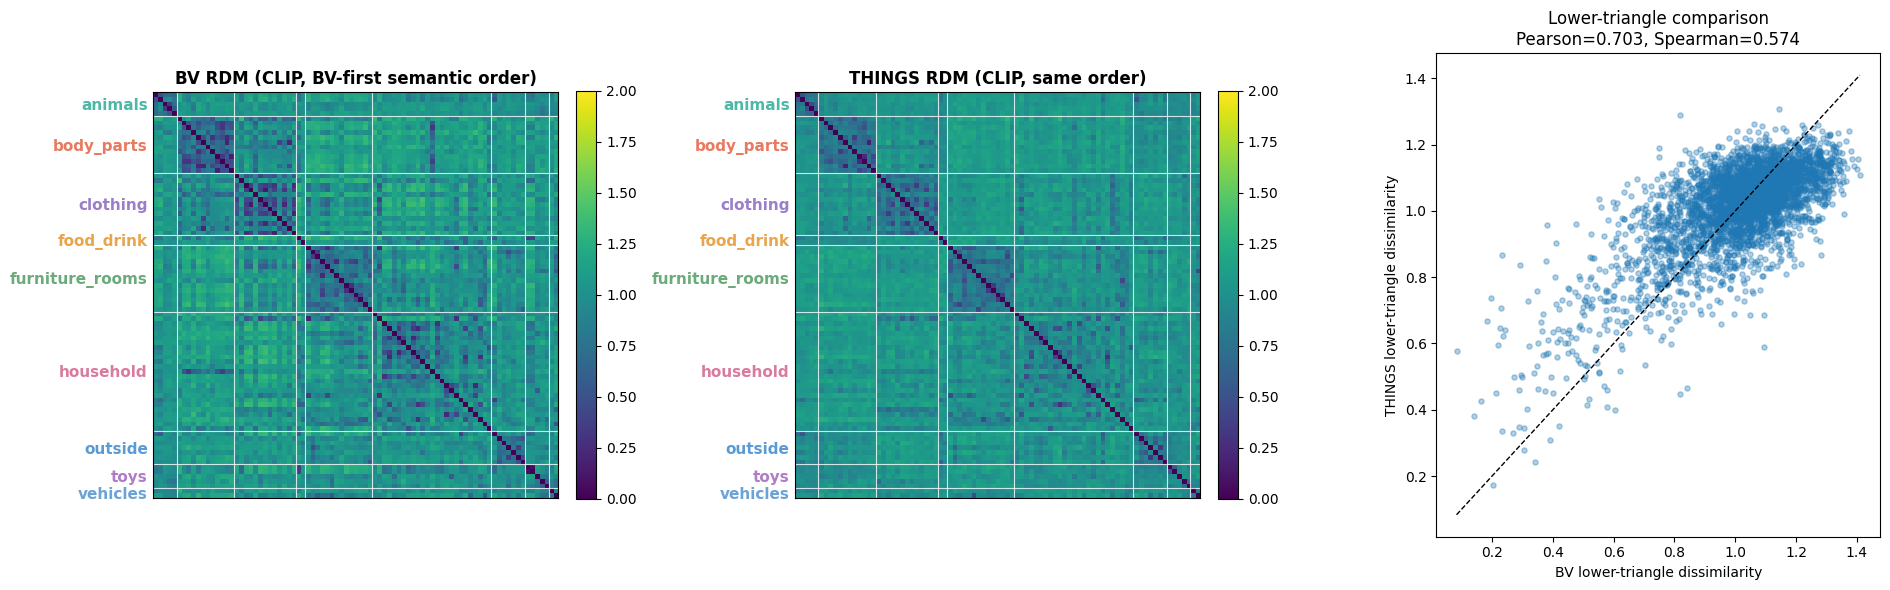

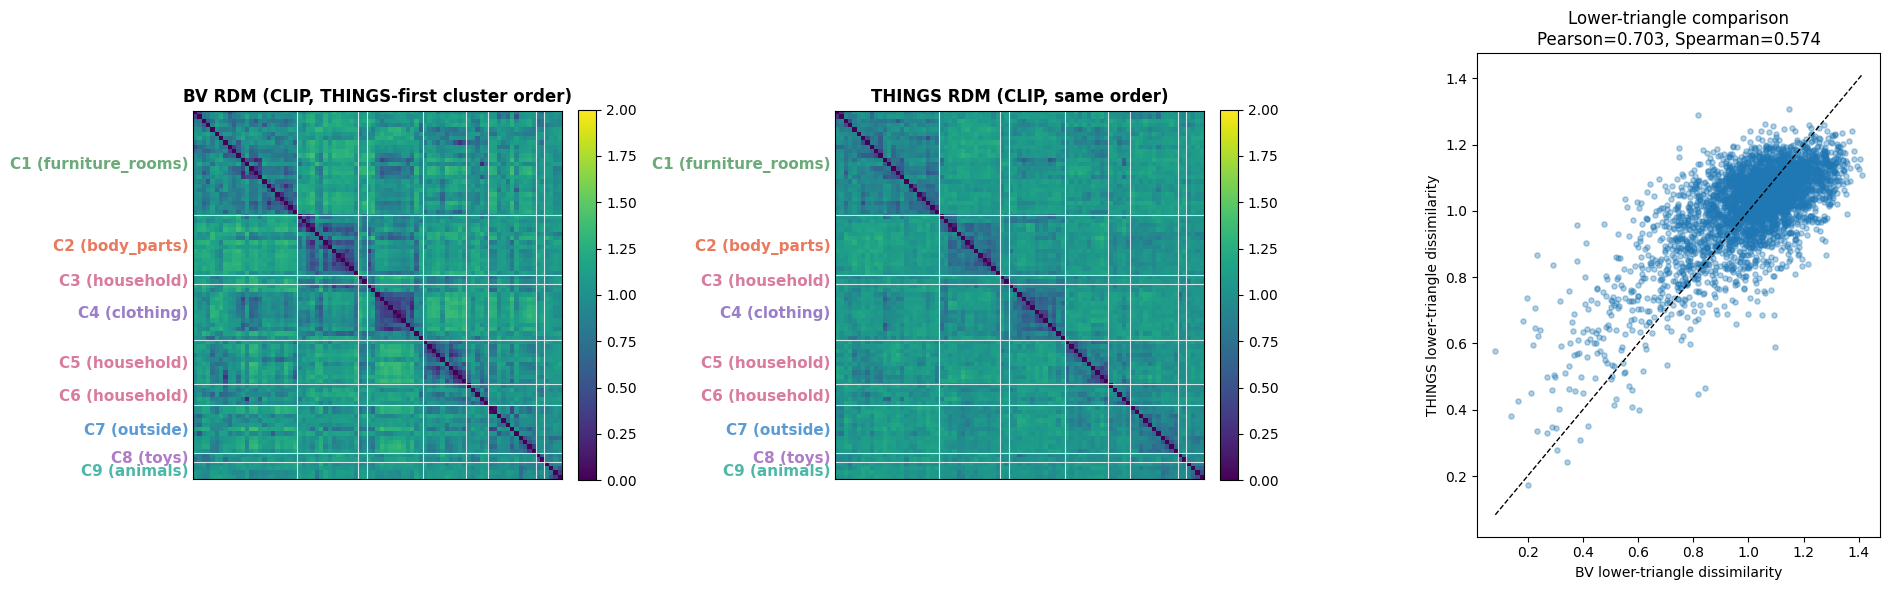

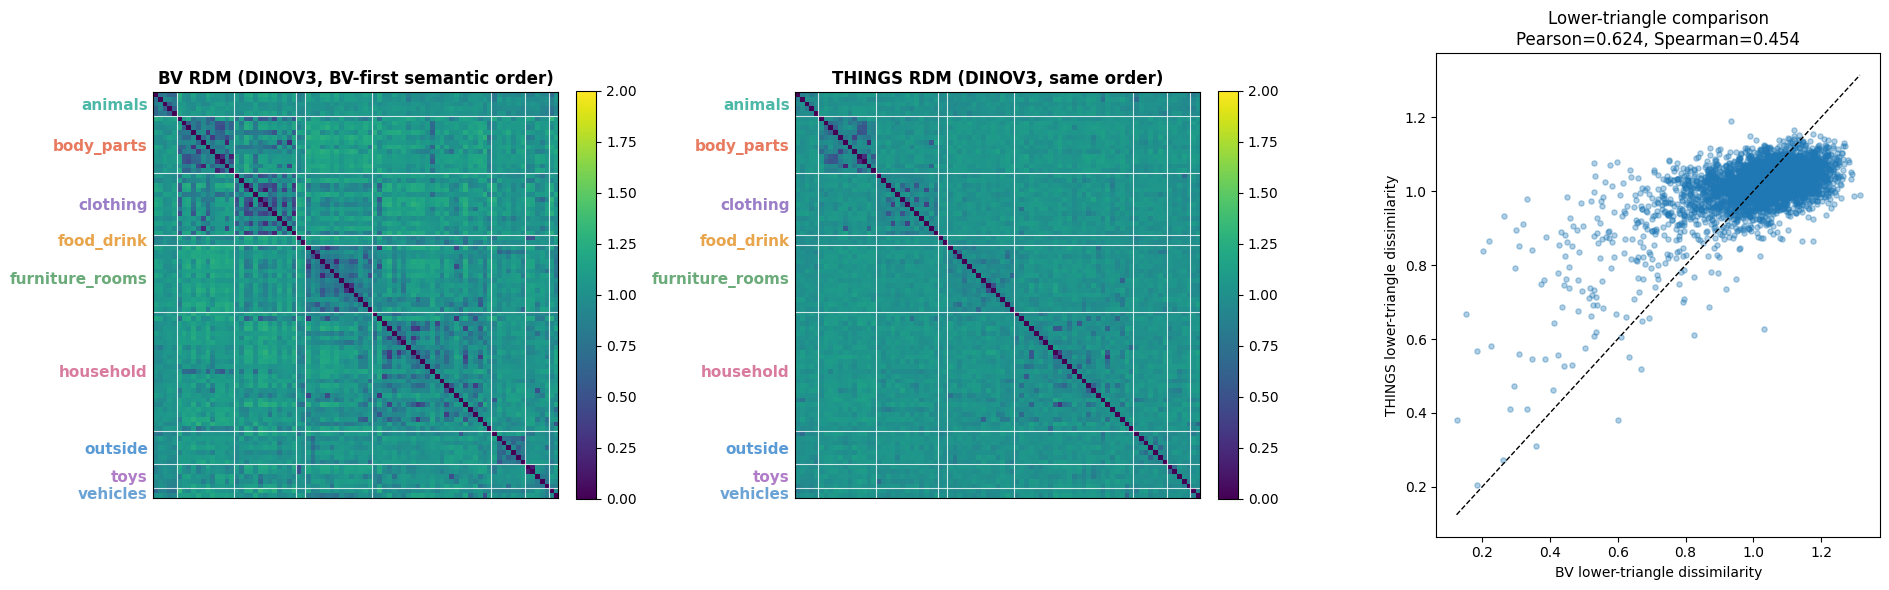

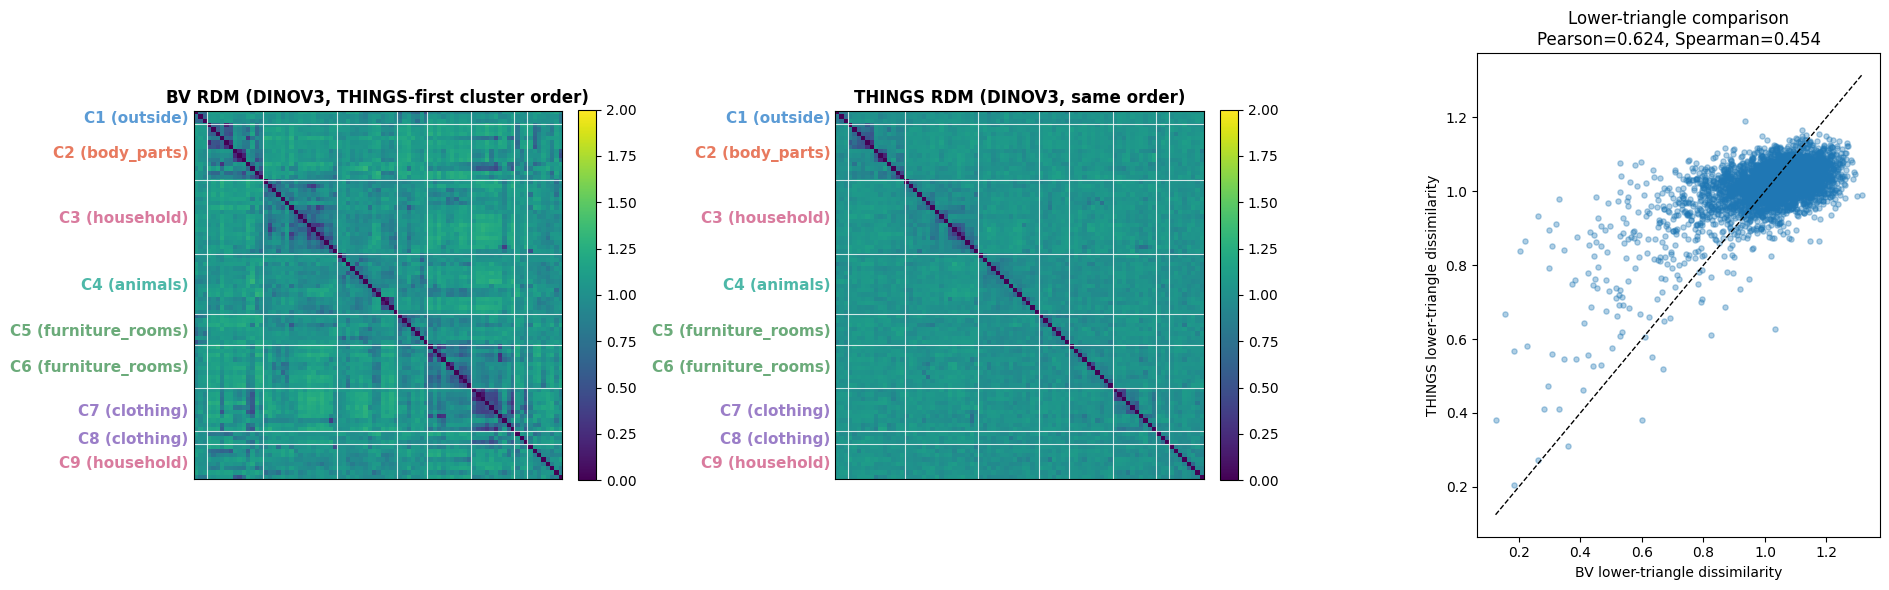

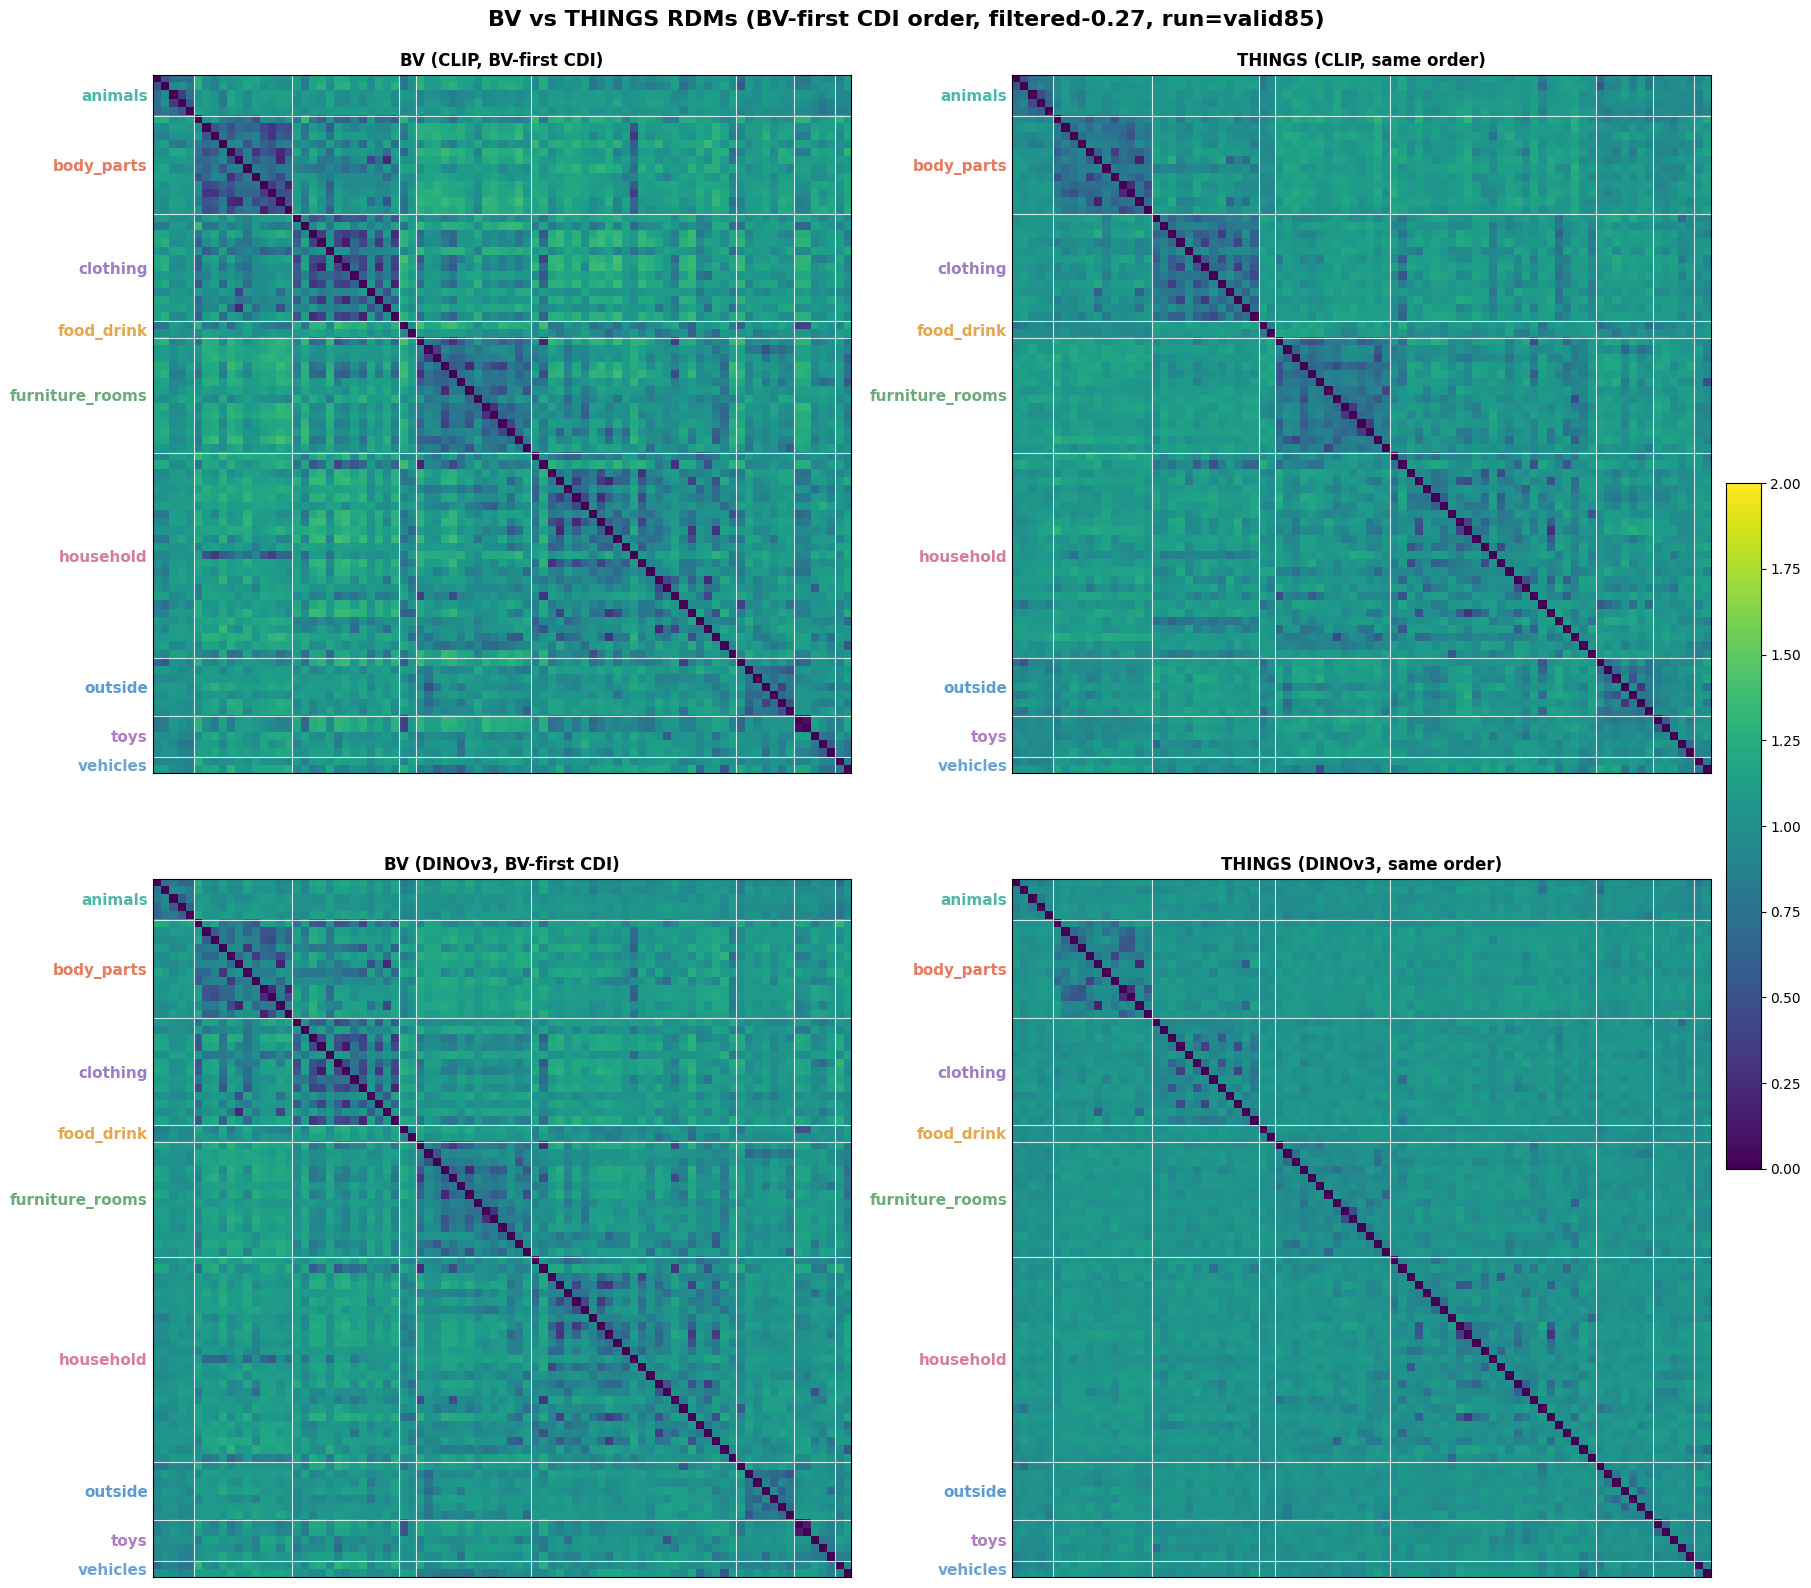

Saved 2x2 BV-first figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_rdm_comparison_2x2_bv_first_clip_dinov3_filtered-0.27_valid85.png
Saved 2x2 BV-first figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_rdm_comparison_2x2_bv_first_clip_dinov3_filtered-0.27_valid85.pdf
Saved summary CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_comparison_summary_v2_lowertri_filtered-0.27_valid85.csv
Saved summary TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_comparison_summary_v2_lowertri_filtered-0.27_valid85.txt


,model,ordering,n_categories,n_pairs,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p,mae,rmse,figure_png,figure_pdf,order_csv
0,clip,bv_first_semantic,85,3570,0.702888,0.0,0.574390,1.483453e-312,0.410494,5.138657e-296,0.105944,0.134988,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
1,clip,things_first_cluster,85,3570,0.702888,0.0,0.574390,1.483453e-312,0.410494,5.138657e-296,0.105944,0.134988,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
2,dinov3,bv_first_semantic,85,3570,0.624011,0.0,0.454278,2.443318e-181,0.316904,2.818099e-177,0.088970,0.119250,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
3,dinov3,things_first_cluster,85,3570,0.624011,0.0,0.454278,2.443318e-181,0.316904,2.818099e-177,0.088970,0.119250,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...


In [23]:
summary_rows_v2 = []
bv_first_panels = {}

if not CDI_SEMANTIC_CSV.exists():
    raise FileNotFoundError(f"Missing CDI semantic mapping CSV: {CDI_SEMANTIC_CSV}")
cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)

if CATEGORY_SET == "valid129":
    VALID_CATEGORIES = sorted(load_included_categories(INCLUDED_CATEGORIES_TXT))
else:
    VALID_CATEGORIES = load_valid_categories(
        INCLUDED_CATEGORIES_TXT,
        PER_CLASS_PRECISION_CSV,
        PRECISION_THRESHOLD,
    )
VALID_SAMPLED_STEMS_BY_CATEGORY = load_valid_sampled_exemplars_by_category(
    PER_FILE_PRECISION_CSV,
    SAMPLED_EXEMPLAR_CSV,
    PRECISION_THRESHOLD,
)

for model_name, paths in EMBEDDING_PAIRS.items():
    bv_csv = paths["bv"]
    th_csv = paths["things"]

    categories, bv_aligned, th_aligned = align_embeddings_for_included_categories(
        bv_csv,
        th_csv,
        VALID_CATEGORIES,
        VALID_SAMPLED_STEMS_BY_CATEGORY,
        require_sampled_stems=(CATEGORY_SET == "valid85"),
    )

    bv_rdm = compute_rdm(bv_aligned)
    th_rdm = compute_rdm(th_aligned)

    # ------------------------------
    # A) BV-first semantic order
    # ------------------------------
    idx_bv, cats_bv, sems_bv, boundaries_bv = build_semantic_cluster_order(categories, cdi_semantic_map)
    bv_rdm_bv = reorder_rdm(bv_rdm, idx_bv)
    th_rdm_bv = reorder_rdm(th_rdm, idx_bv)

    bv_vec_bv = vectorize_lower_triangle(bv_rdm_bv)
    th_vec_bv = vectorize_lower_triangle(th_rdm_bv)
    metrics_bv = compare_rdm_vectors(bv_vec_bv, th_vec_bv)

    block_labels_bv = _cluster_blocks(sems_bv)
    out_prefix_bv = FIGURES_DIR / f"bv_things_rdm_comparison_{model_name}_bv_semantic_lowertri_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}"
    fig_bv_png, fig_bv_pdf = plot_ordered_rdms(
        model_name=model_name,
        version_name="BV-first semantic order",
        bv_rdm_ord=bv_rdm_bv,
        th_rdm_ord=th_rdm_bv,
        bv_vec=bv_vec_bv,
        th_vec=th_vec_bv,
        metrics=metrics_bv,
        boundaries=boundaries_bv,
        block_labels=block_labels_bv,
        out_prefix=out_prefix_bv,
    )

    order_bv_df = pd.DataFrame(
        {
            "position": np.arange(len(cats_bv), dtype=int),
            "category": cats_bv,
            "cdi_semantic": sems_bv,
            "source_order": "bv_first_semantic",
        }
    )
    order_bv_csv = RESULTS_DIR / f"bv_things_rdm_order_bv_semantic_{model_name}_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
    order_bv_df.to_csv(order_bv_csv, index=False)

    summary_rows_v2.append(
        {
            "model": model_name,
            "ordering": "bv_first_semantic",
            "n_categories": len(cats_bv),
            "n_pairs": int(len(bv_vec_bv)),
            **metrics_bv,
            "figure_png": str(fig_bv_png),
            "figure_pdf": str(fig_bv_pdf),
            "order_csv": str(order_bv_csv),
        }
    )

    bv_first_panels[model_name] = {
        "bv_rdm": bv_rdm_bv,
        "th_rdm": th_rdm_bv,
        "boundaries": boundaries_bv,
        "block_labels": block_labels_bv,
    }

    # ------------------------------
    # B) THINGS-first cluster order
    # ------------------------------
    th_order = build_things_cluster_order(
        categories=categories,
        things_rdm=th_rdm,
        cdi_semantic_map=cdi_semantic_map,
        n_clusters=N_THINGS_CLUSTERS,
    )

    idx_th = th_order["order_idx"]
    cats_th = th_order["ordered_categories"]
    sems_th = th_order["ordered_semantics"]
    cluster_ids_th = th_order["ordered_cluster_ids"]
    cluster_labels_th = th_order["ordered_cluster_labels"]
    boundaries_th = th_order["boundaries"]

    bv_rdm_th = reorder_rdm(bv_rdm, idx_th)
    th_rdm_th = reorder_rdm(th_rdm, idx_th)

    bv_vec_th = vectorize_lower_triangle(bv_rdm_th)
    th_vec_th = vectorize_lower_triangle(th_rdm_th)
    metrics_th = compare_rdm_vectors(bv_vec_th, th_vec_th)

    block_labels_th = _cluster_blocks(cluster_labels_th)
    out_prefix_th = FIGURES_DIR / f"bv_things_rdm_comparison_{model_name}_things_cluster_lowertri_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}"
    fig_th_png, fig_th_pdf = plot_ordered_rdms(
        model_name=model_name,
        version_name="THINGS-first cluster order",
        bv_rdm_ord=bv_rdm_th,
        th_rdm_ord=th_rdm_th,
        bv_vec=bv_vec_th,
        th_vec=th_vec_th,
        metrics=metrics_th,
        boundaries=boundaries_th,
        block_labels=block_labels_th,
        out_prefix=out_prefix_th,
    )

    order_th_df = pd.DataFrame(
        {
            "position": np.arange(len(cats_th), dtype=int),
            "category": cats_th,
            "cdi_semantic": sems_th,
            "things_cluster_id": cluster_ids_th,
            "things_cluster_label": cluster_labels_th,
            "source_order": "things_first_cluster",
        }
    )
    order_th_csv = RESULTS_DIR / f"bv_things_rdm_order_things_cluster_{model_name}_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
    order_th_df.to_csv(order_th_csv, index=False)

    summary_rows_v2.append(
        {
            "model": model_name,
            "ordering": "things_first_cluster",
            "n_categories": len(cats_th),
            "n_pairs": int(len(bv_vec_th)),
            **metrics_th,
            "figure_png": str(fig_th_png),
            "figure_pdf": str(fig_th_pdf),
            "order_csv": str(order_th_csv),
        }
    )

combined_2x2_png = None
combined_2x2_pdf = None
if {"clip", "dinov3"}.issubset(bv_first_panels.keys()):
    combined_2x2_png, combined_2x2_pdf = plot_bv_first_combined_2x2_rdms(
        bv_first_panels=bv_first_panels,
        threshold_token=THRESHOLD_TOKEN,
        output_run_tag=OUTPUT_RUN_TAG,
        out_dir=FIGURES_DIR,
    )
    print(f"Saved 2x2 BV-first figure: {combined_2x2_png}")
    print(f"Saved 2x2 BV-first figure: {combined_2x2_pdf}")
else:
    print("Skipping 2x2 BV-first figure: need both clip and dinov3 panels.")

summary_v2_df = pd.DataFrame(summary_rows_v2)
summary_v2_csv = RESULTS_DIR / f"bv_things_rdm_comparison_summary_v2_lowertri_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
summary_v2_txt = RESULTS_DIR / f"bv_things_rdm_comparison_summary_v2_lowertri_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.txt"

summary_v2_df.to_csv(summary_v2_csv, index=False)

lines = [
    f"BV vs THINGS RDM comparison summary (v2, run={OUTPUT_RUN_TAG})",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"CDI semantic mapping: {CDI_SEMANTIC_CSV}",
    f"Threshold: {THRESHOLD}",
    f"N_THINGS_CLUSTERS: {N_THINGS_CLUSTERS}",
    f"combined_2x2_png: {combined_2x2_png if combined_2x2_png is not None else 'not_generated'}",
    f"combined_2x2_pdf: {combined_2x2_pdf if combined_2x2_pdf is not None else 'not_generated'}",
    "",
]

for _, row in summary_v2_df.iterrows():
    lines.extend(
        [
            f"Model: {row['model']} | Ordering: {row['ordering']}",
            f"  n_categories: {int(row['n_categories'])}",
            f"  n_pairs: {int(row['n_pairs'])}",
            f"  pearson_r: {row['pearson_r']:.6f} (p={row['pearson_p']:.3e})",
            f"  spearman_r: {row['spearman_r']:.6f} (p={row['spearman_p']:.3e})",
            f"  kendall_r: {row['kendall_r']:.6f} (p={row['kendall_p']:.3e})",
            f"  mae: {row['mae']:.6f}",
            f"  rmse: {row['rmse']:.6f}",
            f"  figure_png: {row['figure_png']}",
            f"  figure_pdf: {row['figure_pdf']}",
            f"  order_csv: {row['order_csv']}",
            "",
        ]
    )

summary_v2_txt.write_text("\n".join(lines))
print(f"Saved summary CSV: {summary_v2_csv}")
print(f"Saved summary TXT: {summary_v2_txt}")
summary_v2_df

## Cluster labeling

- **BV-first semantic order**: cluster labels are CDI semantic names from `cdi_semantic`.
- **THINGS-first cluster order**: clusters are discovered from THINGS RDM via hierarchical clustering (`average` linkage), then labeled as `Ck (dominant_semantic)` where `dominant_semantic` is the most frequent CDI semantic label in that discovered cluster.
- You can change `N_THINGS_CLUSTERS` in the V2 helper cell.

## Cross-model correlation within BV and THINGS

This section computes RDM correlations between:
- **BV CLIP** vs **BV DINOv3**
- **THINGS CLIP** vs **THINGS DINOv3**

using the same included categories and lower-triangle vectorization.

In [24]:
# Build a common category set across all four embedding tables.
clip_bv_cats, clip_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["bv"])
clip_th_cats, clip_th_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["things"])
dino_bv_cats, dino_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["bv"])
dino_th_cats, dino_th_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["things"])

included = set(load_included_categories(INCLUDED_CATEGORIES_TXT))
common_cats = sorted(
    set(clip_bv_cats)
    & set(clip_th_cats)
    & set(dino_bv_cats)
    & set(dino_th_cats)
    & included
)

clip_bv_idx = {c: i for i, c in enumerate(clip_bv_cats)}
clip_th_idx = {c: i for i, c in enumerate(clip_th_cats)}
dino_bv_idx = {c: i for i, c in enumerate(dino_bv_cats)}
dino_th_idx = {c: i for i, c in enumerate(dino_th_cats)}

clip_bv_aligned = np.stack([clip_bv_emb[clip_bv_idx[c]] for c in common_cats], axis=0)
clip_th_aligned = np.stack([clip_th_emb[clip_th_idx[c]] for c in common_cats], axis=0)
dino_bv_aligned = np.stack([dino_bv_emb[dino_bv_idx[c]] for c in common_cats], axis=0)
dino_th_aligned = np.stack([dino_th_emb[dino_th_idx[c]] for c in common_cats], axis=0)

# So downstream cells can detect stale reuse after CATEGORY_SET / include file changes.
_rdm_align_cache_key = (OUTPUT_RUN_TAG, str(INCLUDED_CATEGORIES_TXT.resolve()))

# RDMs (cosine distance), then lower-triangle vectors.
rdm_clip_bv = compute_rdm(clip_bv_aligned)
rdm_dino_bv = compute_rdm(dino_bv_aligned)
rdm_clip_th = compute_rdm(clip_th_aligned)
rdm_dino_th = compute_rdm(dino_th_aligned)

if rdm_clip_bv.shape != rdm_dino_bv.shape:
    raise ValueError(f"BV RDM shape mismatch: CLIP {rdm_clip_bv.shape} vs DINO {rdm_dino_bv.shape}")
if rdm_clip_th.shape != rdm_dino_th.shape:
    raise ValueError(f"THINGS RDM shape mismatch: CLIP {rdm_clip_th.shape} vs DINO {rdm_dino_th.shape}")
print(f"Verified BV RDM shape (CLIP=DINO): {rdm_clip_bv.shape}")
print(f"Verified THINGS RDM shape (CLIP=DINO): {rdm_clip_th.shape}")

vec_clip_bv = vectorize_lower_triangle(rdm_clip_bv)
vec_dino_bv = vectorize_lower_triangle(rdm_dino_bv)
vec_clip_th = vectorize_lower_triangle(rdm_clip_th)
vec_dino_th = vectorize_lower_triangle(rdm_dino_th)

bv_cross_model = compare_rdm_vectors(vec_clip_bv, vec_dino_bv)
things_cross_model = compare_rdm_vectors(vec_clip_th, vec_dino_th)

cross_model_df = pd.DataFrame(
    [
        {
            "dataset": "bv",
            "model_a": "clip",
            "model_b": "dinov3",
            "n_categories": len(common_cats),
            "n_pairs": int(len(vec_clip_bv)),
            **bv_cross_model,
        },
        {
            "dataset": "things",
            "model_a": "clip",
            "model_b": "dinov3",
            "n_categories": len(common_cats),
            "n_pairs": int(len(vec_clip_th)),
            **things_cross_model,
        },
    ]
)

cross_model_csv = RESULTS_DIR / f"bv_things_cross_model_rdm_correlations_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
cross_model_txt = RESULTS_DIR / f"bv_things_cross_model_rdm_correlations_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.txt"

cross_model_df.to_csv(cross_model_csv, index=False)

lines = [
    f"Cross-model RDM correlations (lower triangle, run={OUTPUT_RUN_TAG})",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"Threshold: {THRESHOLD}",
    f"n_common_categories: {len(common_cats)}",
    "",
]
for _, row in cross_model_df.iterrows():
    lines.extend(
        [
            f"Dataset: {row['dataset']} ({row['model_a']} vs {row['model_b']})",
            f"  n_pairs: {int(row['n_pairs'])}",
            f"  pearson_r: {row['pearson_r']:.6f} (p={row['pearson_p']:.3e})",
            f"  spearman_r: {row['spearman_r']:.6f} (p={row['spearman_p']:.3e})",
            f"  kendall_r: {row['kendall_r']:.6f} (p={row['kendall_p']:.3e})",
            f"  mae: {row['mae']:.6f}",
            f"  rmse: {row['rmse']:.6f}",
            "",
        ]
    )

cross_model_txt.write_text("\n".join(lines))

print(f"Saved CSV: {cross_model_csv}")
print(f"Saved TXT: {cross_model_txt}")
cross_model_df


Verified BV RDM shape (CLIP=DINO): (85, 85)
Verified THINGS RDM shape (CLIP=DINO): (85, 85)
Saved CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_cross_model_rdm_correlations_filtered-0.27_valid85.csv
Saved TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_cross_model_rdm_correlations_filtered-0.27_valid85.txt


,dataset,model_a,model_b,n_categories,n_pairs,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p,mae,rmse
0,bv,clip,dinov3,85,3570,0.888768,0.0,0.839000,0.000000e+00,0.653615,0.000000e+00,0.070333,0.088757
1,things,clip,dinov3,85,3570,0.701937,0.0,0.514016,5.017022e-240,0.362104,8.152500e-231,0.075592,0.096782


## Per-semantic-cluster cross-model correlations

This computes CLIP-vs-DINOv3 RDM correlation **within each CDI semantic cluster** for:
- BV
- THINGS

Using lower-triangle vectorization on the sub-RDM for each cluster.

In [25]:
# Reuse aligned embeddings from the cross-model cell when they match this run (tag + include file).
# Otherwise rebuild (e.g. this cell run alone, or kernel still has arrays from a previous run).
_rdm_key = (OUTPUT_RUN_TAG, str(INCLUDED_CATEGORIES_TXT.resolve()))
if (
    "common_cats" not in globals()
    or "dino_th_aligned" not in globals()
    or globals().get("_rdm_align_cache_key") != _rdm_key
):
    clip_bv_cats, clip_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["bv"])
    clip_th_cats, clip_th_emb = load_embedding_csv(EMBEDDING_PAIRS["clip"]["things"])
    dino_bv_cats, dino_bv_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["bv"])
    dino_th_cats, dino_th_emb = load_embedding_csv(EMBEDDING_PAIRS["dinov3"]["things"])

    included = set(load_included_categories(INCLUDED_CATEGORIES_TXT))
    common_cats = sorted(
        set(clip_bv_cats)
        & set(clip_th_cats)
        & set(dino_bv_cats)
        & set(dino_th_cats)
        & included
    )

    clip_bv_idx = {c: i for i, c in enumerate(clip_bv_cats)}
    clip_th_idx = {c: i for i, c in enumerate(clip_th_cats)}
    dino_bv_idx = {c: i for i, c in enumerate(dino_bv_cats)}
    dino_th_idx = {c: i for i, c in enumerate(dino_th_cats)}

    clip_bv_aligned = np.stack([clip_bv_emb[clip_bv_idx[c]] for c in common_cats], axis=0)
    clip_th_aligned = np.stack([clip_th_emb[clip_th_idx[c]] for c in common_cats], axis=0)
    dino_bv_aligned = np.stack([dino_bv_emb[dino_bv_idx[c]] for c in common_cats], axis=0)
    dino_th_aligned = np.stack([dino_th_emb[dino_th_idx[c]] for c in common_cats], axis=0)

    _rdm_align_cache_key = _rdm_key

if "cdi_semantic_map" not in globals() or globals().get("_cdi_semantic_csv") != str(CDI_SEMANTIC_CSV.resolve()):
    cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)
    _cdi_semantic_csv = str(CDI_SEMANTIC_CSV.resolve())

sem_to_indices = {}
for i, cat in enumerate(common_cats):
    sem = cdi_semantic_map.get(cat, "other")
    sem_to_indices.setdefault(sem, []).append(i)

rows = []

# CDI_SEMANTIC_ORDER first, then any remaining labels present in the data (e.g. people).
_sem_in_order = [s for s in CDI_SEMANTIC_ORDER if s in sem_to_indices]
_sem_extra = sorted(set(sem_to_indices) - set(_sem_in_order))
for sem in _sem_in_order + _sem_extra:
    idx = sem_to_indices[sem]
    if len(idx) < 3:
        # Need at least 3 categories for a meaningful lower-triangle vector.
        continue

    clip_bv_sub = clip_bv_aligned[idx, :]
    dino_bv_sub = dino_bv_aligned[idx, :]
    clip_th_sub = clip_th_aligned[idx, :]
    dino_th_sub = dino_th_aligned[idx, :]

    vec_clip_bv_sub = vectorize_lower_triangle(compute_rdm(clip_bv_sub))
    vec_dino_bv_sub = vectorize_lower_triangle(compute_rdm(dino_bv_sub))
    vec_clip_th_sub = vectorize_lower_triangle(compute_rdm(clip_th_sub))
    vec_dino_th_sub = vectorize_lower_triangle(compute_rdm(dino_th_sub))

    bv_stats = compare_rdm_vectors(vec_clip_bv_sub, vec_dino_bv_sub)
    th_stats = compare_rdm_vectors(vec_clip_th_sub, vec_dino_th_sub)

    rows.append(
        {
            "semantic_cluster": sem,
            "n_categories": len(idx),
            "n_pairs": int(len(vec_clip_bv_sub)),
            "bv_pearson_r": bv_stats["pearson_r"],
            "bv_spearman_r": bv_stats["spearman_r"],
            "bv_kendall_r": bv_stats["kendall_r"],
            "things_pearson_r": th_stats["pearson_r"],
            "things_spearman_r": th_stats["spearman_r"],
            "things_kendall_r": th_stats["kendall_r"],
        }
    )

cluster_corr_df = pd.DataFrame(rows).sort_values("bv_spearman_r", ascending=False).reset_index(drop=True)

cluster_corr_csv = RESULTS_DIR / f"bv_things_cross_model_cluster_correlations_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
cluster_corr_txt = RESULTS_DIR / f"bv_things_cross_model_cluster_correlations_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.txt"
cluster_corr_df.to_csv(cluster_corr_csv, index=False)

lines = [
    f"Per-semantic-cluster CLIP-vs-DINOv3 RDM correlations (lower triangle, run={OUTPUT_RUN_TAG})",
    "",
    f"Included categories file: {INCLUDED_CATEGORIES_TXT}",
    f"n_common_categories: {len(common_cats)}",
    f"Saved CSV: {cluster_corr_csv}",
    "",
    "Ranked by BV Spearman r:",
]
for _, r in cluster_corr_df.iterrows():
    lines.append(
        f"- {r['semantic_cluster']:<16} n={int(r['n_categories']):2d} | "
        f"BV sp={r['bv_spearman_r']:.3f}, TH sp={r['things_spearman_r']:.3f}"
    )

cluster_corr_txt.write_text("\n".join(lines))
print(f"Saved CSV: {cluster_corr_csv}")
print(f"Saved TXT: {cluster_corr_txt}")

# Quick views
print("\nTop clusters by BV Spearman:")
display(cluster_corr_df.sort_values("bv_spearman_r", ascending=False).head(5))

print("\nTop clusters by THINGS Spearman:")
display(cluster_corr_df.sort_values("things_spearman_r", ascending=False).head(5))

cluster_corr_df


Saved CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_cross_model_cluster_correlations_filtered-0.27_valid85.csv
Saved TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_cross_model_cluster_correlations_filtered-0.27_valid85.txt

Top clusters by BV Spearman:


,semantic_cluster,n_categories,n_pairs,bv_pearson_r,bv_spearman_r,bv_kendall_r,things_pearson_r,things_spearman_r,things_kendall_r
0,clothing,13,78,0.972664,0.966970,0.854812,0.847089,0.832598,0.643024
1,toys,5,10,0.971081,0.951515,0.822222,0.932216,0.684848,0.555556
2,outside,7,21,0.906160,0.946753,0.809524,0.820951,0.725974,0.580952
3,household,25,300,0.909121,0.867588,0.692620,0.826524,0.673917,0.494849
4,body_parts,12,66,0.880946,0.860349,0.677389,0.818713,0.656236,0.467599



Top clusters by THINGS Spearman:


,semantic_cluster,n_categories,n_pairs,bv_pearson_r,bv_spearman_r,bv_kendall_r,things_pearson_r,things_spearman_r,things_kendall_r
0,clothing,13,78,0.972664,0.966970,0.854812,0.847089,0.832598,0.643024
2,outside,7,21,0.906160,0.946753,0.809524,0.820951,0.725974,0.580952
1,toys,5,10,0.971081,0.951515,0.822222,0.932216,0.684848,0.555556
3,household,25,300,0.909121,0.867588,0.692620,0.826524,0.673917,0.494849
4,body_parts,12,66,0.880946,0.860349,0.677389,0.818713,0.656236,0.467599


,semantic_cluster,n_categories,n_pairs,bv_pearson_r,bv_spearman_r,bv_kendall_r,things_pearson_r,things_spearman_r,things_kendall_r
0,clothing,13,78,0.972664,0.966970,0.854812,0.847089,0.832598,0.643024
1,toys,5,10,0.971081,0.951515,0.822222,0.932216,0.684848,0.555556
2,outside,7,21,0.906160,0.946753,0.809524,0.820951,0.725974,0.580952
3,household,25,300,0.909121,0.867588,0.692620,0.826524,0.673917,0.494849
4,body_parts,12,66,0.880946,0.860349,0.677389,0.818713,0.656236,0.467599
5,furniture_rooms,14,91,0.858808,0.797372,0.609768,0.718535,0.567256,0.408547
6,animals,5,10,0.825417,0.793939,0.600000,0.567573,0.418182,0.377778


## Visualization: cluster correlation rankings

This section visualizes per-semantic-cluster CLIP-vs-DINOv3 correlations for BV and THINGS.
- Ranked horizontal bar plots
- Compact heatmap-style summary

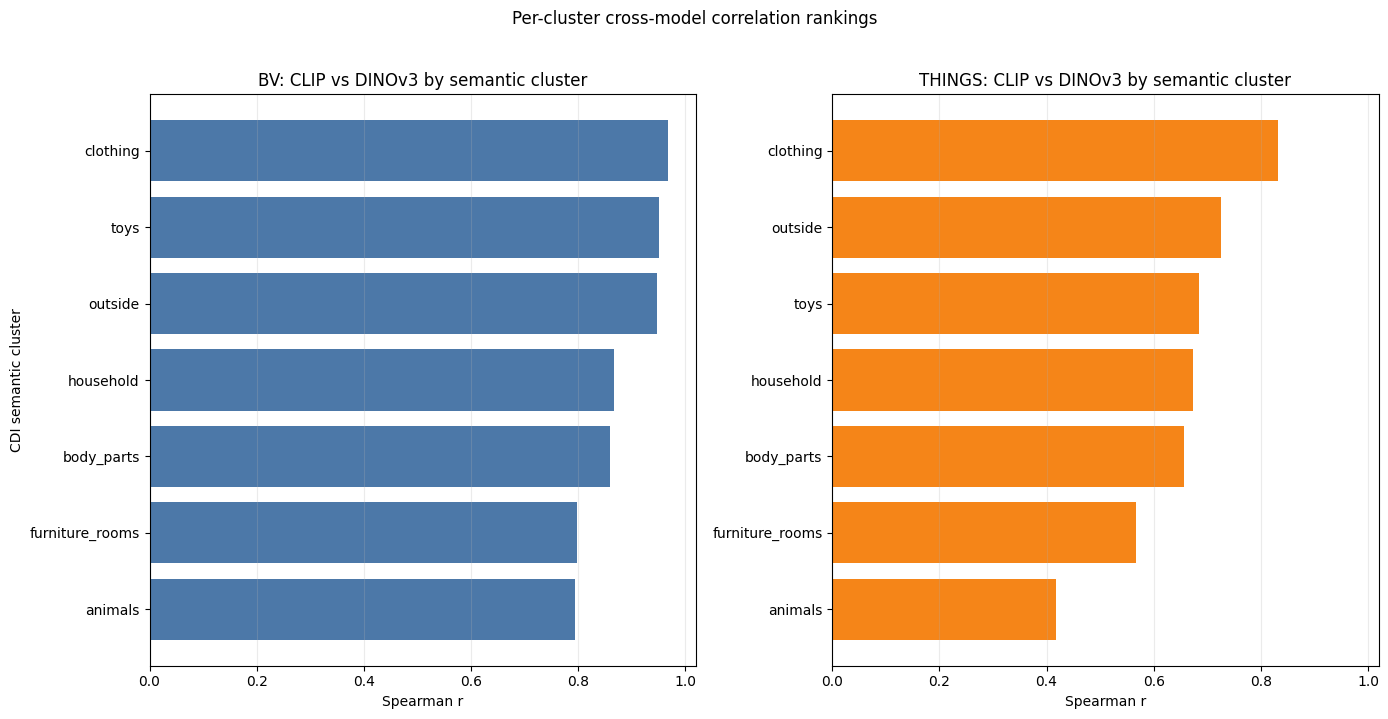

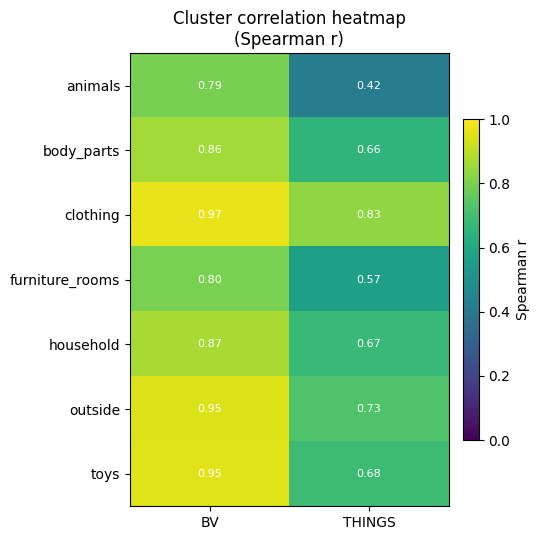

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_cross_model_cluster_rankings_filtered-0.27_valid85.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_cross_model_cluster_rankings_filtered-0.27_valid85.pdf
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_cross_model_cluster_heatmap_filtered-0.27_valid85.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_cross_model_cluster_heatmap_filtered-0.27_valid85.pdf


In [26]:
# If needed, load per-cluster results from disk.
if "cluster_corr_df" not in globals():
    cluster_corr_csv = RESULTS_DIR / f"bv_things_cross_model_cluster_correlations_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
    if not cluster_corr_csv.exists():
        raise FileNotFoundError(f"Missing cluster correlation CSV: {cluster_corr_csv}")
    cluster_corr_df = pd.read_csv(cluster_corr_csv)

# Keep semantic order for consistent colors/order fallback.
sem_rank = {s: i for i, s in enumerate(CDI_SEMANTIC_ORDER)}
plot_df = cluster_corr_df.copy()
plot_df["rank_bv"] = plot_df["bv_spearman_r"].rank(ascending=False, method="min")
plot_df["rank_things"] = plot_df["things_spearman_r"].rank(ascending=False, method="min")

# --------------------------
# Figure 1: ranked bar plots
# --------------------------
bv_sorted = plot_df.sort_values("bv_spearman_r", ascending=True)
th_sorted = plot_df.sort_values("things_spearman_r", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

axes[0].barh(bv_sorted["semantic_cluster"], bv_sorted["bv_spearman_r"], color="#4C78A8")
axes[0].set_title("BV: CLIP vs DINOv3 by semantic cluster")
axes[0].set_xlabel("Spearman r")
axes[0].set_ylabel("CDI semantic cluster")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(th_sorted["semantic_cluster"], th_sorted["things_spearman_r"], color="#F58518")
axes[1].set_title("THINGS: CLIP vs DINOv3 by semantic cluster")
axes[1].set_xlabel("Spearman r")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

for ax in axes:
    ax.set_xlim(0, 1.02)

fig.suptitle("Per-cluster cross-model correlation rankings", y=1.02)
fig.tight_layout()

rank_png = FIGURES_DIR / f"bv_things_cross_model_cluster_rankings_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.png"
rank_pdf = FIGURES_DIR / f"bv_things_cross_model_cluster_rankings_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.pdf"
fig.savefig(rank_png, dpi=220, bbox_inches="tight")
fig.savefig(rank_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

# --------------------------------
# Figure 2: compact heatmap summary
# --------------------------------
heat_df = (
    plot_df[["semantic_cluster", "bv_spearman_r", "things_spearman_r"]]
    .set_index("semantic_cluster")
    .reindex(sorted(plot_df["semantic_cluster"], key=lambda s: sem_rank.get(s, 999)))
)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
im = ax.imshow(heat_df.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["BV", "THINGS"])
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("Cluster correlation heatmap\n(Spearman r)")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        v = heat_df.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman r")
fig.tight_layout()

heat_png = FIGURES_DIR / f"bv_things_cross_model_cluster_heatmap_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.png"
heat_pdf = FIGURES_DIR / f"bv_things_cross_model_cluster_heatmap_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.pdf"
fig.savefig(heat_png, dpi=220, bbox_inches="tight")
fig.savefig(heat_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {rank_png}")
print(f"Saved: {rank_pdf}")
print(f"Saved: {heat_png}")
print(f"Saved: {heat_pdf}")

## Compare `valid85` vs `valid129` outputs

The next cell expects **two** saved cross-model summaries (CLIP vs DINO RDM correlation, lower triangle), produced by running this notebook with each category set:

| Category set | Environment | Include file |
|---------|-------------|--------------|
| `valid85` | `CATEGORY_SET = "valid85"` | `data/included_categories_valid85.txt` |
| `valid129` | `CATEGORY_SET = "valid129"` | `data/included_categories_valid129.txt` |

Files read (same naming as notebook 02):

- `supplemental_results_valid85cats_04202026/results/bv_things_cross_model_rdm_correlations_filtered-{threshold}_valid85.csv`
- `main_results_valid129s_04202026/results/bv_things_cross_model_rdm_correlations_filtered-{threshold}_valid129.csv`

**Ways to produce both:** run `python analysis/preprint-2026/run_03_rdm_dual.py` from the repo root (uses `jupyter nbconvert` twice), or execute this notebook end-to-end twice while changing `CATEGORY_SET` in setup (`valid85`, then `valid129`). Then run the cell below: it merges those CSVs, shows the table, plots **Pearson *r*** for BV and THINGS by category set, and saves `bv_things_cross_model_rdm_comparison_valid85_vs_valid129_filtered-{threshold}.png` under `analysis/preprint-2026/results/` (shared cross-run folder).

In [27]:
# # Load cross-model summaries from both category-set runs (if present)
# comparison_specs = [
#     (
#         "valid85",
#         PREPRINT_DIR / "supplemental_results_valid85cats_04302026" / "results",
#         "valid85 (included_categories_valid85.txt ∩ embeddings)",
#     ),
#     (
#         "valid129",
#         PREPRINT_DIR / "main_results_valid129s_04302026" / "results",
#         "valid129 (included_categories_valid129.txt ∩ embeddings)",
#     ),
# ]
# PREPRINT_SHARED_RESULTS = PREPRINT_DIR / "results"
# PREPRINT_SHARED_RESULTS.mkdir(parents=True, exist_ok=True)

# frames = []
# for tag, results_dir, label in comparison_specs:
#     p = results_dir / f"bv_things_cross_model_rdm_correlations_filtered-{THRESHOLD_TOKEN}_{tag}.csv"
#     if not p.exists():
#         print(f"Missing (run notebook 03 with CATEGORY_SET={tag!r}): {p}")
#         continue
#     df = pd.read_csv(p)
#     df["category_set"] = label
#     frames.append(df)

# if len(frames) >= 2:
#     comb = pd.concat(frames, ignore_index=True)
#     display(comb.sort_values(["dataset", "category_set"]))
#     pivot = comb.pivot_table(
#         index="dataset", columns="category_set", values="pearson_r", aggfunc="first"
#     )
#     ax = pivot.plot(kind="bar", figsize=(8, 4), rot=0, width=0.75)
#     ax.set_ylabel("Pearson r (CLIP vs DINO RDM)")
#     ax.set_title(f"Cross-model RDM agreement by dataset (threshold {THRESHOLD_TOKEN})")
#     ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
#     plt.tight_layout()
#     cmp_fig = (
#         PREPRINT_SHARED_RESULTS
#         / f"bv_things_cross_model_rdm_comparison_valid85_vs_valid129_filtered-{THRESHOLD_TOKEN}.png"
#     )
#     plt.savefig(cmp_fig, dpi=200, bbox_inches="tight")
#     print(f"Saved comparison figure: {cmp_fig}")
# elif len(frames) == 1:
#     print("Only one run found; execute the other CATEGORY_SET to compare.")
# else:
#     print("No cross-model CSVs found yet; run the notebook (or run_03_rdm_dual.py) first.")

In [28]:
# Baseline package for BV-vs-THINGS RDM comparison
# Includes:
# 1) Label-shuffle permutation null for BV↔THINGS (per model)
# 2) Internal anchors: CLIP↔DINO within BV and within THINGS
# 3) Coarse semantic block-model baseline

import os

N_PERMUTATIONS = int(os.environ.get("BV_RDM_BASELINE_N_PERM", "5000"))
RNG_SEED = int(os.environ.get("BV_RDM_BASELINE_SEED", "2026"))
rng = np.random.default_rng(RNG_SEED)

# Keep CDI map in memory.
if "cdi_semantic_map" not in globals() or globals().get("_cdi_semantic_csv") != str(CDI_SEMANTIC_CSV.resolve()):
    cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)
    _cdi_semantic_csv = str(CDI_SEMANTIC_CSV.resolve())


def _shared_category_order(*dfs):
    shared = set(dfs[0].index)
    for d in dfs[1:]:
        shared &= set(d.index)
    if "INCLUDED_CATEGORIES" in globals():
        return [c for c in INCLUDED_CATEGORIES if c in shared]
    return sorted(shared)


def _semantic_block_rdm(categories, semantic_map):
    sem = [semantic_map.get(c, "other") for c in categories]
    n = len(categories)
    block = np.ones((n, n), dtype=float)
    for i in range(n):
        block[i, i] = 0.0
        for j in range(i + 1, n):
            same = sem[i] == sem[j]
            d = 0.0 if same else 1.0
            block[i, j] = d
            block[j, i] = d
    return block


def _perm_spearman_against_shuffled_labels(reference_rdm, target_rdm, n_perm=5000, rng_obj=None):
    if rng_obj is None:
        rng_obj = np.random.default_rng(0)
    n = reference_rdm.shape[0]
    ref_vec = vectorize_lower_triangle(reference_rdm)
    perm_r = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        idx = rng_obj.permutation(n)
        tgt_perm = target_rdm[np.ix_(idx, idx)]
        tgt_vec = vectorize_lower_triangle(tgt_perm)
        perm_r[i] = float(spearmanr(ref_vec, tgt_vec).statistic)
    return perm_r


rdm_store = {}
vec_store = {}
baseline_rows = []

included = set(load_included_categories(INCLUDED_CATEGORIES_TXT))

for model_name in EMBEDDING_PAIRS.keys():
    bv_cats, bv_emb_raw = load_embedding_csv(EMBEDDING_PAIRS[model_name]["bv"])
    th_cats, th_emb_raw = load_embedding_csv(EMBEDDING_PAIRS[model_name]["things"])

    bv_cat_set = set(bv_cats)
    th_cat_set = set(th_cats)
    cat_order_source = INCLUDED_CATEGORIES if "INCLUDED_CATEGORIES" in globals() else sorted(included)
    cats = [c for c in cat_order_source if c in included and c in bv_cat_set and c in th_cat_set]

    if len(cats) < 3:
        raise ValueError(f"Need >=3 shared categories for {model_name}, found {len(cats)}")

    bv_idx = {c: i for i, c in enumerate(bv_cats)}
    th_idx = {c: i for i, c in enumerate(th_cats)}
    bv_emb = np.stack([bv_emb_raw[bv_idx[c]] for c in cats], axis=0)
    th_emb = np.stack([th_emb_raw[th_idx[c]] for c in cats], axis=0)

    bv_rdm = compute_rdm(bv_emb)
    th_rdm = compute_rdm(th_emb)

    rdm_store.setdefault(model_name, {})["bv"] = bv_rdm
    rdm_store.setdefault(model_name, {})["things"] = th_rdm

    bv_vec = vectorize_lower_triangle(bv_rdm)
    th_vec = vectorize_lower_triangle(th_rdm)
    vec_store.setdefault(model_name, {})["bv"] = bv_vec
    vec_store.setdefault(model_name, {})["things"] = th_vec

    obs = compare_rdm_vectors(bv_vec, th_vec)
    perm = _perm_spearman_against_shuffled_labels(
        reference_rdm=bv_rdm,
        target_rdm=th_rdm,
        n_perm=N_PERMUTATIONS,
        rng_obj=rng,
    )
    obs_r = float(obs["spearman_r"])
    p_emp_two_sided = float((1 + np.sum(np.abs(perm) >= abs(obs_r))) / (N_PERMUTATIONS + 1))
    z_emp = float((obs_r - perm.mean()) / (perm.std(ddof=1) + 1e-12))

    # Coarse semantic baseline (same categories/order, binary same-vs-different semantic labels).
    sem_block_rdm = _semantic_block_rdm(cats, cdi_semantic_map)
    sem_block_vec = vectorize_lower_triangle(sem_block_rdm)
    sem_vs_bv = compare_rdm_vectors(bv_vec, sem_block_vec)
    sem_vs_th = compare_rdm_vectors(th_vec, sem_block_vec)

    baseline_rows.append(
        {
            "model": model_name,
            "n_categories": len(cats),
            "n_pairs": len(bv_vec),
            "bv_vs_things_spearman_r": obs_r,
            "bv_vs_things_pearson_r": float(obs["pearson_r"]),
            "perm_null_mean_spearman": float(perm.mean()),
            "perm_null_sd_spearman": float(perm.std(ddof=1)),
            "perm_empirical_p_two_sided": p_emp_two_sided,
            "perm_empirical_z": z_emp,
            "semantic_block_vs_bv_spearman_r": float(sem_vs_bv["spearman_r"]),
            "semantic_block_vs_things_spearman_r": float(sem_vs_th["spearman_r"]),
        }
    )

# Internal anchors: cross-model agreement within each dataset.
for dataset_name in ("bv", "things"):
    if not all(k in rdm_store for k in ("clip", "dinov3")):
        continue
    a = vec_store["clip"][dataset_name]
    b = vec_store["dinov3"][dataset_name]
    stats = compare_rdm_vectors(a, b)
    baseline_rows.append(
        {
            "model": "clip_vs_dinov3_anchor",
            "n_categories": int(rdm_store["clip"][dataset_name].shape[0]),
            "n_pairs": len(a),
            "anchor_dataset": dataset_name,
            "anchor_cross_model_spearman_r": float(stats["spearman_r"]),
            "anchor_cross_model_pearson_r": float(stats["pearson_r"]),
        }
    )

baseline_df = pd.DataFrame(baseline_rows)

baseline_csv = RESULTS_DIR / f"bv_things_rdm_baselines_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
baseline_txt = RESULTS_DIR / f"bv_things_rdm_baselines_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.txt"
baseline_df.to_csv(baseline_csv, index=False)

lines = [
    f"BV-vs-THINGS RDM baseline summary (run={OUTPUT_RUN_TAG})",
    f"Threshold token: {THRESHOLD_TOKEN}",
    f"N permutations: {N_PERMUTATIONS}",
    f"Seed: {RNG_SEED}",
    "",
]
for _, r in baseline_df.iterrows():
    if r.get("model") == "clip_vs_dinov3_anchor":
        lines.extend(
            [
                f"[{r['model']}] dataset={r.get('anchor_dataset', 'NA')}",
                f"  cross_model_spearman_r: {r.get('anchor_cross_model_spearman_r', np.nan):.6f}",
                f"  cross_model_pearson_r: {r.get('anchor_cross_model_pearson_r', np.nan):.6f}",
                "",
            ]
        )
    else:
        lines.extend(
            [
                f"[{r['model']}] n_categories={int(r['n_categories'])}, n_pairs={int(r['n_pairs'])}",
                f"  bv_vs_things_spearman_r: {r['bv_vs_things_spearman_r']:.6f}",
                f"  bv_vs_things_pearson_r: {r['bv_vs_things_pearson_r']:.6f}",
                f"  perm_empirical_p_two_sided: {r['perm_empirical_p_two_sided']:.6g}",
                f"  perm_empirical_z: {r['perm_empirical_z']:.6f}",
                f"  semantic_block_vs_bv_spearman_r: {r['semantic_block_vs_bv_spearman_r']:.6f}",
                f"  semantic_block_vs_things_spearman_r: {r['semantic_block_vs_things_spearman_r']:.6f}",
                "",
            ]
        )
baseline_txt.write_text("\n".join(lines))

print(f"Saved baseline CSV: {baseline_csv}")
print(f"Saved baseline TXT: {baseline_txt}")
display(baseline_df)

Saved baseline CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_baselines_filtered-0.27_valid85.csv
Saved baseline TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_baselines_filtered-0.27_valid85.txt


,model,n_categories,n_pairs,bv_vs_things_spearman_r,bv_vs_things_pearson_r,perm_null_mean_spearman,perm_null_sd_spearman,perm_empirical_p_two_sided,perm_empirical_z,semantic_block_vs_bv_spearman_r,semantic_block_vs_things_spearman_r,anchor_dataset,anchor_cross_model_spearman_r,anchor_cross_model_pearson_r
0,clip,85,3570,0.574390,0.702888,-0.000494,0.016347,0.0002,35.167748,0.376625,0.402165,NaN,NaN,NaN
1,dinov3,85,3570,0.454278,0.624011,-0.000172,0.016944,0.0002,26.820175,0.346547,0.318962,NaN,NaN,NaN
2,clip_vs_dinov3_anchor,85,3570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bv,0.839000,0.888768
3,clip_vs_dinov3_anchor,85,3570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,things,0.514016,0.701937


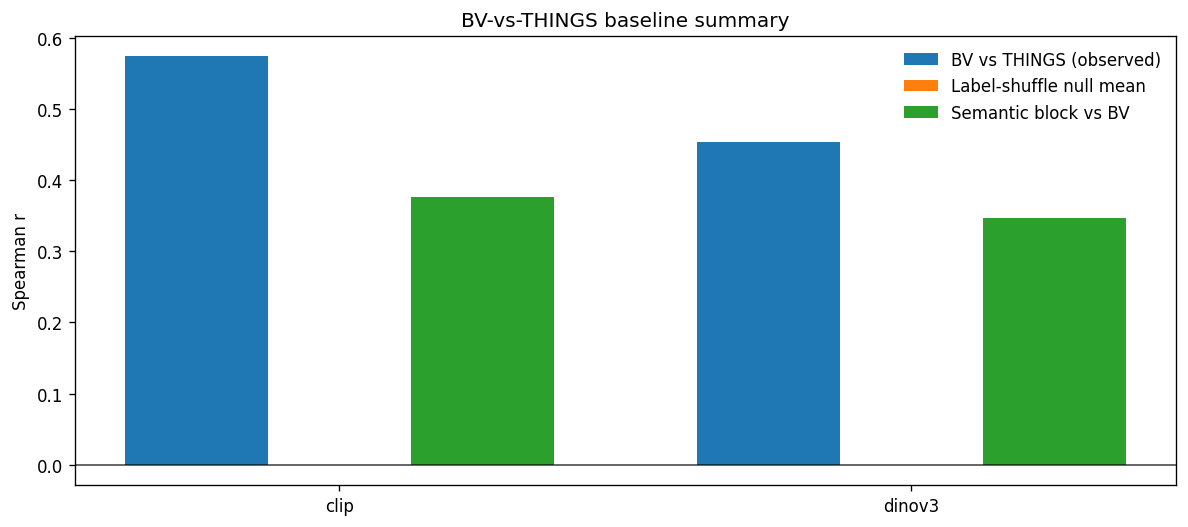

Saved baseline summary plot: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_rdm_baselines_summary_filtered-0.27_valid85.png
Saved baseline summary plot: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_rdm_baselines_summary_filtered-0.27_valid85.pdf


In [29]:
# Baseline summary plot (observed BV-vs-THINGS vs null/semantic baselines)
plot_df = baseline_df[baseline_df["model"] != "clip_vs_dinov3_anchor"].copy()

if not plot_df.empty:
    plot_df = plot_df.sort_values("model")
    x = np.arange(len(plot_df))
    w = 0.25

    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
    ax.bar(x - w, plot_df["bv_vs_things_spearman_r"], width=w, label="BV vs THINGS (observed)")
    ax.bar(x, plot_df["perm_null_mean_spearman"], width=w, label="Label-shuffle null mean")
    ax.bar(x + w, plot_df["semantic_block_vs_bv_spearman_r"], width=w, label="Semantic block vs BV")

    ax.axhline(0.0, color="black", linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["model"].tolist())
    ax.set_ylabel("Spearman r")
    ax.set_title("BV-vs-THINGS baseline summary")
    ax.legend(frameon=False, ncol=1)

    fig.tight_layout()

    base_png = FIGURES_DIR / f"bv_things_rdm_baselines_summary_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.png"
    base_pdf = FIGURES_DIR / f"bv_things_rdm_baselines_summary_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.pdf"
    fig.savefig(base_png, dpi=220, bbox_inches="tight")
    fig.savefig(base_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved baseline summary plot: {base_png}")
    print(f"Saved baseline summary plot: {base_pdf}")
else:
    print("No model rows available for baseline summary plotting.")

## Additional null baselines: category-order shuffle and edge-value shuffle

This section adds two stricter nulls for BV-vs-THINGS RDM agreement (per model):

- **Category-order shuffle (independent):** randomly permute category order in BV and THINGS separately before correlating lower triangles.
- **Edge-value shuffle:** keep BV lower-triangle fixed, shuffle THINGS lower-triangle values (destroys pair identity while preserving distance histogram).

These complement the label-shuffle baseline above and help show whether observed correlations are meaningfully above chance.

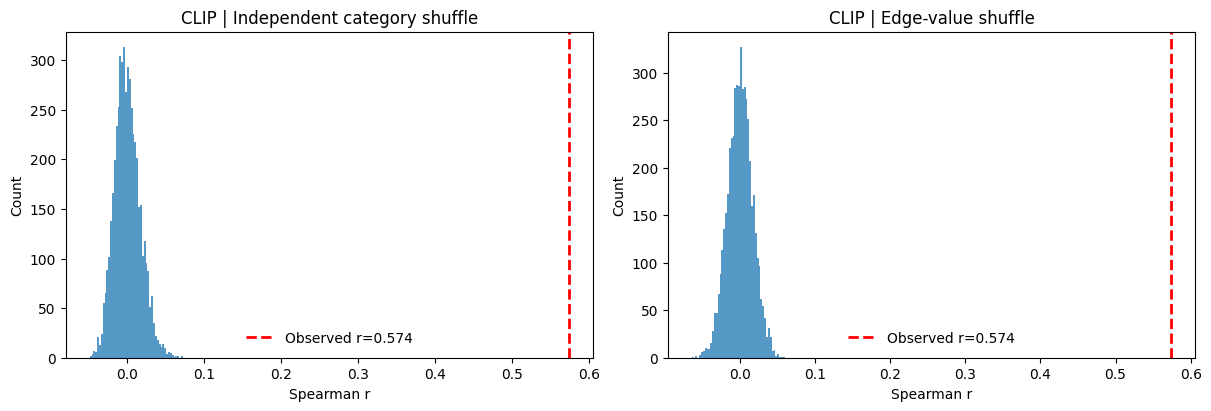

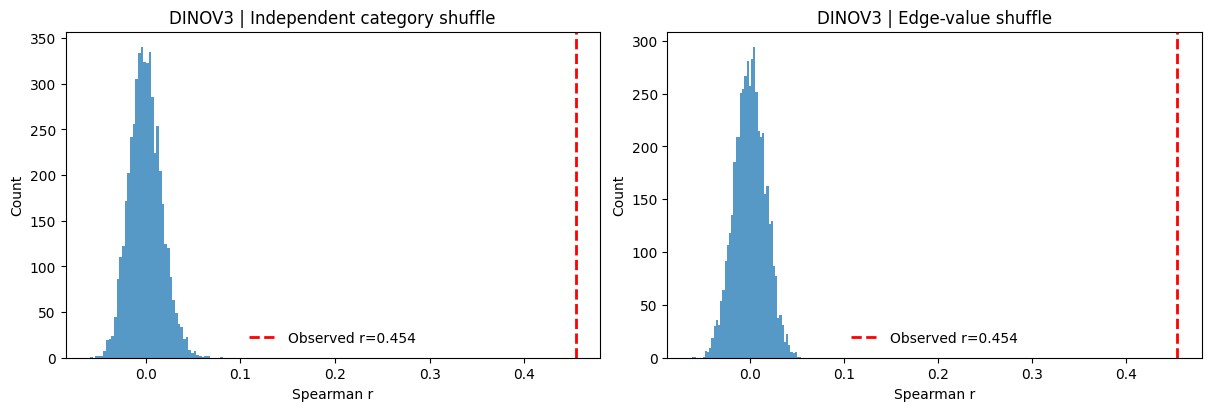

Saved additional baseline CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_baselines_additional_filtered-0.27_valid85.csv
Saved additional baseline TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/bv_things_rdm_baselines_additional_filtered-0.27_valid85.txt
Saved null histogram (clip): /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_rdm_additional_nulls_clip_filtered-0.27_valid85.png
Saved null histogram (clip): /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/bv_things_rdm_additional_nulls_clip_filtered-0.27_valid85.pdf
Saved null histogram (dinov3): /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/suppleme

,model,baseline,observed_spearman_r,null_mean_spearman_r,null_sd_spearman_r,empirical_p_two_sided,empirical_z,n_categories,n_pairs,n_permutations
0,clip,edge_value_shuffle,0.574390,0.000147,0.016694,0.0002,34.397373,85,3570,5000
1,clip,independent_category_shuffle,0.574390,-0.000008,0.016800,0.0002,34.190169,85,3570,5000
2,dinov3,edge_value_shuffle,0.454278,-0.000096,0.016406,0.0002,27.696012,85,3570,5000
3,dinov3,independent_category_shuffle,0.454278,-0.000351,0.016940,0.0002,26.838065,85,3570,5000


In [30]:
# Additional baseline battery built from rdm_store / vec_store (created in the baseline cell above).
if "rdm_store" not in globals() or "vec_store" not in globals():
    raise RuntimeError("Run the baseline cell above first to populate rdm_store and vec_store.")

rng_extra = np.random.default_rng(RNG_SEED + 101)


def _permute_rdm(rdm: np.ndarray, idx: np.ndarray) -> np.ndarray:
    return rdm[np.ix_(idx, idx)]


def _independent_category_shuffle_null(
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    n_perm: int,
    rng_obj,
) -> np.ndarray:
    """Shuffle BV and THINGS category orders independently each permutation."""
    n = bv_rdm.shape[0]
    out = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        idx_bv = rng_obj.permutation(n)
        idx_th = rng_obj.permutation(n)
        bv_vec = vectorize_lower_triangle(_permute_rdm(bv_rdm, idx_bv))
        th_vec = vectorize_lower_triangle(_permute_rdm(th_rdm, idx_th))
        out[i] = float(spearmanr(bv_vec, th_vec).statistic)
    return out


def _edge_value_shuffle_null(
    bv_vec: np.ndarray,
    th_vec: np.ndarray,
    n_perm: int,
    rng_obj,
) -> np.ndarray:
    """Shuffle THINGS pairwise distances (preserves histogram, breaks correspondence)."""
    out = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        out[i] = float(spearmanr(bv_vec, rng_obj.permutation(th_vec)).statistic)
    return out


extra_rows = []
hist_paths = []

for model_name in ("clip", "dinov3"):
    if model_name not in rdm_store:
        continue

    bv_rdm = rdm_store[model_name]["bv"]
    th_rdm = rdm_store[model_name]["things"]
    bv_vec = vec_store[model_name]["bv"]
    th_vec = vec_store[model_name]["things"]

    obs = float(spearmanr(bv_vec, th_vec).statistic)

    null_cat = _independent_category_shuffle_null(
        bv_rdm=bv_rdm,
        th_rdm=th_rdm,
        n_perm=N_PERMUTATIONS,
        rng_obj=rng_extra,
    )
    null_edge = _edge_value_shuffle_null(
        bv_vec=bv_vec,
        th_vec=th_vec,
        n_perm=N_PERMUTATIONS,
        rng_obj=rng_extra,
    )

    for baseline_name, null_dist in (
        ("independent_category_shuffle", null_cat),
        ("edge_value_shuffle", null_edge),
    ):
        p_two = float((1 + np.sum(np.abs(null_dist) >= abs(obs))) / (len(null_dist) + 1))
        z = float((obs - null_dist.mean()) / (null_dist.std(ddof=1) + 1e-12))
        extra_rows.append(
            {
                "model": model_name,
                "baseline": baseline_name,
                "observed_spearman_r": obs,
                "null_mean_spearman_r": float(null_dist.mean()),
                "null_sd_spearman_r": float(null_dist.std(ddof=1)),
                "empirical_p_two_sided": p_two,
                "empirical_z": z,
                "n_categories": int(bv_rdm.shape[0]),
                "n_pairs": int(len(bv_vec)),
                "n_permutations": int(len(null_dist)),
            }
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for ax, null_dist, title in (
        (axes[0], null_cat, "Independent category shuffle"),
        (axes[1], null_edge, "Edge-value shuffle"),
    ):
        ax.hist(null_dist, bins=50, alpha=0.75)
        ax.axvline(obs, color="red", linestyle="--", linewidth=2, label=f"Observed r={obs:.3f}")
        ax.set_title(f"{model_name.upper()} | {title}")
        ax.set_xlabel("Spearman r")
        ax.set_ylabel("Count")
        ax.legend(loc="best", frameon=False)

    hist_png = FIGURES_DIR / f"bv_things_rdm_additional_nulls_{model_name}_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.png"
    hist_pdf = FIGURES_DIR / f"bv_things_rdm_additional_nulls_{model_name}_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.pdf"
    fig.savefig(hist_png, dpi=200, bbox_inches="tight")
    fig.savefig(hist_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    hist_paths.append((model_name, hist_png, hist_pdf))

extra_df = pd.DataFrame(extra_rows).sort_values(["model", "baseline"]).reset_index(drop=True)
extra_csv = RESULTS_DIR / f"bv_things_rdm_baselines_additional_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.csv"
extra_txt = RESULTS_DIR / f"bv_things_rdm_baselines_additional_filtered-{THRESHOLD_TOKEN}_{OUTPUT_RUN_TAG}.txt"
extra_df.to_csv(extra_csv, index=False)

lines = [
    f"Additional BV-vs-THINGS baseline summary (run={OUTPUT_RUN_TAG})",
    f"Threshold token: {THRESHOLD_TOKEN}",
    f"N permutations: {N_PERMUTATIONS}",
    f"Seed: {RNG_SEED + 101}",
    "",
]
for _, r in extra_df.iterrows():
    lines.extend(
        [
            f"[{r['model']}] {r['baseline']}",
            f"  observed_spearman_r: {r['observed_spearman_r']:.6f}",
            f"  null_mean_spearman_r: {r['null_mean_spearman_r']:.6f}",
            f"  null_sd_spearman_r: {r['null_sd_spearman_r']:.6f}",
            f"  empirical_p_two_sided: {r['empirical_p_two_sided']:.6g}",
            f"  empirical_z: {r['empirical_z']:.6f}",
            "",
        ]
    )

if hist_paths:
    lines.append("Histogram figures:")
    for model_name, p_png, p_pdf in hist_paths:
        lines.append(f"- {model_name}: {p_png}")
        lines.append(f"- {model_name}: {p_pdf}")

extra_txt.write_text("\n".join(lines))
print(f"Saved additional baseline CSV: {extra_csv}")
print(f"Saved additional baseline TXT: {extra_txt}")
for model_name, p_png, p_pdf in hist_paths:
    print(f"Saved null histogram ({model_name}): {p_png}")
    print(f"Saved null histogram ({model_name}): {p_pdf}")

display(extra_df)
